# ActionFlow: Motion and Appearance Baselines on KTH

This notebook is the primary source of truth for the ActionFlow project. It runs three end-to-end experiments on the [KTH Actions dataset](https://www.csc.kth.se/cvap/actions/):

1. Optical Flow model - a ResNet-18 trained on stacked dense Farneback flow fields (20-channel input: 10 frame pairs x 2 displacement axes).
2. Single-Frame Appearance baseline - a ResNet-18 trained on the center frame from each clip.
3. Temporal Appearance baseline - a ResNet-18 trained on stacked grayscale frames sampled across time.

The notebook is cache-aware and CPU-friendly by default. On a GPU machine it expands to the full dataset automatically; on CPU it prepares smaller train/val/test subsets per class so the whole pipeline stays runnable.



In [1]:
%matplotlib inline

import json
import sys
import time
from dataclasses import dataclass, replace
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

sys.path.insert(0, str(Path("src").resolve()))

from actionflow.data.dataset import (
    FlowClipDataset,
    RGBClipDataset,
    TemporalAppearanceClipDataset,
    TEST_PERSONS,
    TRAIN_PERSONS,
    VAL_PERSONS,
    extract_person_id,
    get_train_val_test_split,
)
from actionflow.data.flow import compute_video_flow, visualize_flow
from actionflow.data.frames import extract_video_frames
from actionflow.models.resnet_flow import build_resnet18_flow
from actionflow.training.metrics import (
    classification_report,
    compute_accuracy,
    compute_confusion_matrix,
    plot_confusion_matrix,
    plot_training_curves,
)
from actionflow.training.trainer import Trainer
from actionflow.utils.seed import seed_everything

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


c:\Coding\ActionFlow\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 3070 Ti
VRAM: 8.0 GB


## 1. Configuration

The config dataclass controls the notebook pipeline.

- Device: auto-detected - CUDA if available, otherwise CPU.
- CPU defaults: smaller image size, smaller batch size, fewer epochs, and a per-class train/val/test subset so the notebook remains practical to execute locally.
- GPU defaults: full dataset, larger batch size, 30 epochs, and pretrained backbones.
- Set `train_videos_per_class`, `val_videos_per_class`, and `test_videos_per_class` to `None` if you want the full KTH split on CPU too.



In [2]:
USE_GPU = torch.cuda.is_available()


@dataclass
class ActionFlowConfig:
    data_root: Path = Path("data/kth")
    raw_root: Path = Path("data/kth/raw")
    class_names: tuple[str, ...] = (
        "boxing",
        "handclapping",
        "handwaving",
        "jogging",
        "running",
        "walking",
    )
    resize: tuple[int, int] = (224, 224) if USE_GPU else (112, 112)
    clip_length: int = 10
    frame_stride: int = 2

    # CPU-friendly defaults. Set these to None to use the full dataset.
    train_videos_per_class: int | None = None if USE_GPU else 3
    val_videos_per_class: int | None = None if USE_GPU else 1
    test_videos_per_class: int | None = None if USE_GPU else 2

    mode: str = "flow"
    pretrained_backbone: bool = USE_GPU
    batch_size: int = 16 if USE_GPU else 4
    epochs: int = 30 if USE_GPU else 2
    lr: float = 1e-3
    weight_decay: float = 1e-4
    scheduler: str = "cosine"
    device: str = "cuda" if USE_GPU else "cpu"
    num_workers: int = 0 if sys.platform.startswith("win") else (2 if USE_GPU else 0)
    seed: int = 42
    output_dir: Path = Path("outputs/flow")

    def __post_init__(self) -> None:
        if self.mode not in {"flow", "rgb", "appearance_single", "appearance_temporal"}:
            raise ValueError("mode must be 'flow', 'rgb', 'appearance_single', or 'appearance_temporal'.")
        self.num_classes = len(self.class_names)
        if self.mode == "flow":
            self.input_channels = self.clip_length * 2
        elif self.mode == "appearance_temporal":
            self.input_channels = self.clip_length
        else:
            self.input_channels = 3


config = ActionFlowConfig()
config.output_dir.mkdir(parents=True, exist_ok=True)

if sys.platform.startswith("win") and config.num_workers == 0:
    print("Using num_workers=0 for notebook-safe DataLoaders on Windows.")

display(
    pd.DataFrame(
        {
            "value": {
                "device": config.device,
                "mode": config.mode,
                "resize": f"{config.resize[0]}x{config.resize[1]}",
                "clip_length": config.clip_length,
                "frame_stride": config.frame_stride,
                "input_channels": config.input_channels,
                "pretrained_backbone": config.pretrained_backbone,
                "batch_size": config.batch_size,
                "epochs": config.epochs,
                "lr": config.lr,
                "scheduler": config.scheduler,
                "num_workers": config.num_workers,
                "pin_memory": config.device == "cuda",
                "train_videos_per_class": str(config.train_videos_per_class or "all"),
                "val_videos_per_class": str(config.val_videos_per_class or "all"),
                "test_videos_per_class": str(config.test_videos_per_class or "all"),
            }
        }
    )
)



Using num_workers=0 for notebook-safe DataLoaders on Windows.


,value
device,cuda
mode,flow
resize,224x224
clip_length,10
frame_stride,2
input_channels,20
pretrained_backbone,True
batch_size,16
epochs,30
lr,0.001


## 2. Pipeline Helpers

This cell keeps the notebook-specific glue while reusing the canonical code under `src/actionflow/data`:

- Download check: only downloads a class if its `.avi` files are missing.
- Notebook subset selection: uses the official KTH train/val/test person split so even CPU runs preserve the evaluation protocol.
- Frame extraction: reuses `extract_video_frames`.
- Optical flow: reuses `compute_video_flow`.
- Dataset classes: reuses `FlowClipDataset`, `RGBClipDataset`, and `TemporalAppearanceClipDataset`.
- Inline evaluation: keeps the notebook-friendly plots and tables.



In [3]:
NOTEBOOK_SAMPLE_CLASSES = ("boxing", "running", "handwaving")
NOTEBOOK_SAMPLE_FLOW_CLASSES = ("boxing", "walking")


def ensure_kth_downloaded(config: ActionFlowConfig) -> Path:
    import urllib.request
    import zipfile

    base_url = "https://www.csc.kth.se/cvap/actions"
    raw_root = config.raw_root
    raw_root.mkdir(parents=True, exist_ok=True)

    for action in config.class_names:
        avi_dir = raw_root / action
        if avi_dir.exists() and list(avi_dir.glob("*.avi")):
            print(f"[SKIP] {action} already downloaded")
            continue
        avi_dir.mkdir(parents=True, exist_ok=True)
        zip_path = raw_root / f"{action}.zip"
        url = f"{base_url}/{action}.zip"
        print(f"[DOWNLOADING] {action}.zip ...")
        urllib.request.urlretrieve(url, zip_path)
        print(f"[EXTRACTING] {action}.zip")
        with zipfile.ZipFile(zip_path, "r") as zip_file:
            zip_file.extractall(avi_dir)
        zip_path.unlink()

    total_videos = sum(len(list((raw_root / class_name).glob("*.avi"))) for class_name in config.class_names)
    if total_videos <= 0:
        raise FileNotFoundError(f"No AVI files found under {raw_root}")
    print(f"Download complete. {total_videos} videos available.")
    return raw_root


def summarize_raw_videos(raw_root: Path, class_names: tuple[str, ...]) -> pd.DataFrame:
    rows = []
    for class_name in class_names:
        avis = list((raw_root / class_name).glob("*.avi"))
        rows.append({"class": class_name, "avi_files": len(avis)})
    return pd.DataFrame(rows)


def select_videos_for_notebook(raw_root: Path, class_names: tuple[str, ...], train_per_class: int | None, val_per_class: int | None, test_per_class: int | None) -> tuple[list[Path], pd.DataFrame]:
    selected: list[Path] = []
    rows: list[dict[str, int | str]] = []
    for class_name in class_names:
        avi_paths = sorted((raw_root / class_name).glob("*.avi"))
        train_videos = [path for path in avi_paths if extract_person_id(path.stem) in TRAIN_PERSONS]
        val_videos = [path for path in avi_paths if extract_person_id(path.stem) in VAL_PERSONS]
        test_videos = [path for path in avi_paths if extract_person_id(path.stem) in TEST_PERSONS]
        if train_per_class is not None:
            train_videos = train_videos[:train_per_class]
        if val_per_class is not None:
            val_videos = val_videos[:val_per_class]
        if test_per_class is not None:
            test_videos = test_videos[:test_per_class]
        selected.extend(train_videos)
        selected.extend(val_videos)
        selected.extend(test_videos)
        rows.append({"class": class_name, "train_videos": len(train_videos), "val_videos": len(val_videos), "test_videos": len(test_videos), "total_selected": len(train_videos) + len(val_videos) + len(test_videos)})
    return selected, pd.DataFrame(rows)


def extract_frames_for_selected(avi_paths: list[Path], raw_root: Path, frames_root: Path, resize: tuple[int, int]) -> int:
    total_created = 0
    for avi_path in tqdm(avi_paths, desc="Frame extraction", unit="video"):
        relative = avi_path.relative_to(raw_root).with_suffix("")
        stats = extract_video_frames(avi_path, frames_root / relative, resize)
        total_created += int(stats["created"])
    return total_created


def compute_flow_for_selected(avi_paths: list[Path], raw_root: Path, frames_root: Path, flow_root: Path) -> int:
    total_created = 0
    for avi_path in tqdm(avi_paths, desc="Optical flow", unit="video"):
        relative = avi_path.relative_to(raw_root).with_suffix("")
        stats = compute_video_flow(frames_root / relative, flow_root / relative)
        total_created += int(stats["created"])
    return total_created


def first_available_video_dir(prepared_root: Path, class_name: str) -> Path:
    class_root = prepared_root / class_name
    video_dirs = sorted(path for path in class_root.iterdir() if path.is_dir()) if class_root.exists() else []
    if not video_dirs:
        raise FileNotFoundError(f"No prepared videos found for class {class_name!r} under {prepared_root}")
    return video_dirs[0]


def build_loader(dataset, config: ActionFlowConfig, shuffle: bool) -> DataLoader:
    return DataLoader(dataset, batch_size=config.batch_size, shuffle=shuffle, num_workers=config.num_workers, pin_memory=config.device == "cuda")


def evaluate_model_inline(model: torch.nn.Module, data_loader: DataLoader, class_names: tuple[str, ...], device: str, output_dir: Path, mode: str) -> dict[str, object]:
    model.eval()
    all_preds: list[int] = []
    all_labels: list[int] = []
    with torch.no_grad():
        for inputs, labels in data_loader:
            logits = model(inputs.to(device))
            all_preds.extend(logits.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.tolist())
    accuracy = compute_accuracy(all_preds, all_labels)
    confusion = compute_confusion_matrix(all_preds, all_labels, class_names)
    report = classification_report(all_preds, all_labels, class_names)
    fig = plot_confusion_matrix(confusion, class_names, output_dir / f"confusion_matrix_{mode}.png")
    display(fig)
    plt.close(fig)
    metrics = {"mode": mode, "accuracy": accuracy, "macro_f1": float(report["macro avg"]["f1-score"]), "weighted_f1": float(report["weighted avg"]["f1-score"]), "confusion_matrix": confusion.tolist(), "classification_report": report}
    with (output_dir / f"metrics_{mode}.json").open("w", encoding="utf-8") as handle:
        json.dump(metrics, handle, indent=2)
    print(f"Test accuracy: {accuracy:.4f} | Macro F1: {metrics['macro_f1']:.4f}")
    display(pd.DataFrame(report).transpose().round(3))
    return metrics


print("Notebook helpers ready.")



Notebook helpers ready.


## 3. Dataset Acquisition

The raw KTH videos live under `data/kth/raw/{class}`. If the dataset is already present, the download step becomes a no-op.

After confirming the raw data, the notebook picks the exact videos it will prepare using the official person split:

- GPU: the full train/val/test split.
- CPU: a smaller person-balanced train/val/test subset per class using the same protocol.



In [4]:
seed_everything(config.seed)
raw_root = ensure_kth_downloaded(config)
frames_root = config.data_root / "frames"
flow_root = config.data_root / "flow"

selected_avis, selection_summary = select_videos_for_notebook(
    raw_root,
    config.class_names,
    train_per_class=config.train_videos_per_class,
    val_per_class=config.val_videos_per_class,
    test_per_class=config.test_videos_per_class,
)

print(f"Raw dataset: {raw_root}")
raw_summary = summarize_raw_videos(raw_root, config.class_names)
raw_summary["total_videos"] = raw_summary["avi_files"].cumsum()
display(raw_summary)
print(f"Total videos available: {raw_summary['avi_files'].sum()}")

display(
    Markdown(
        f"**Notebook subset:** {len(selected_avis)} videos prepared "
        f"({config.train_videos_per_class or 'all'} train, "
        f"{config.val_videos_per_class or 'all'} val, "
        f"{config.test_videos_per_class or 'all'} test per class)."
    )
)
display(selection_summary)



[SKIP] boxing already downloaded
[SKIP] handclapping already downloaded
[SKIP] handwaving already downloaded
[SKIP] jogging already downloaded
[SKIP] running already downloaded
[SKIP] walking already downloaded
Download complete. 599 videos available.
Raw dataset: data\kth\raw


,class,avi_files,total_videos
0,boxing,100,100
1,handclapping,99,199
2,handwaving,100,299
3,jogging,100,399
4,running,100,499
5,walking,100,599


Total videos available: 599


**Notebook subset:** 599 videos prepared (all train, all val, all test per class).

,class,train_videos,val_videos,test_videos,total_selected
0,boxing,48,16,36,100
1,handclapping,48,15,36,99
2,handwaving,48,16,36,100
3,jogging,48,16,36,100
4,running,48,16,36,100
5,walking,48,16,36,100


## 4. Preprocessing: Frame Extraction

The notebook extracts PNG frames only for the selected videos. Outputs are written under `data/kth/frames/{class}/{video}/frame_XXXXX.png` using the configured resize value.

This keeps the path practical while preserving the same person-based split logic as the full pipeline.

Frame extraction: 100%|██████████| 599/599 [00:08<00:00, 74.81video/s]


Prepared frames for 599 videos in 8.0s (0 new PNG files written).


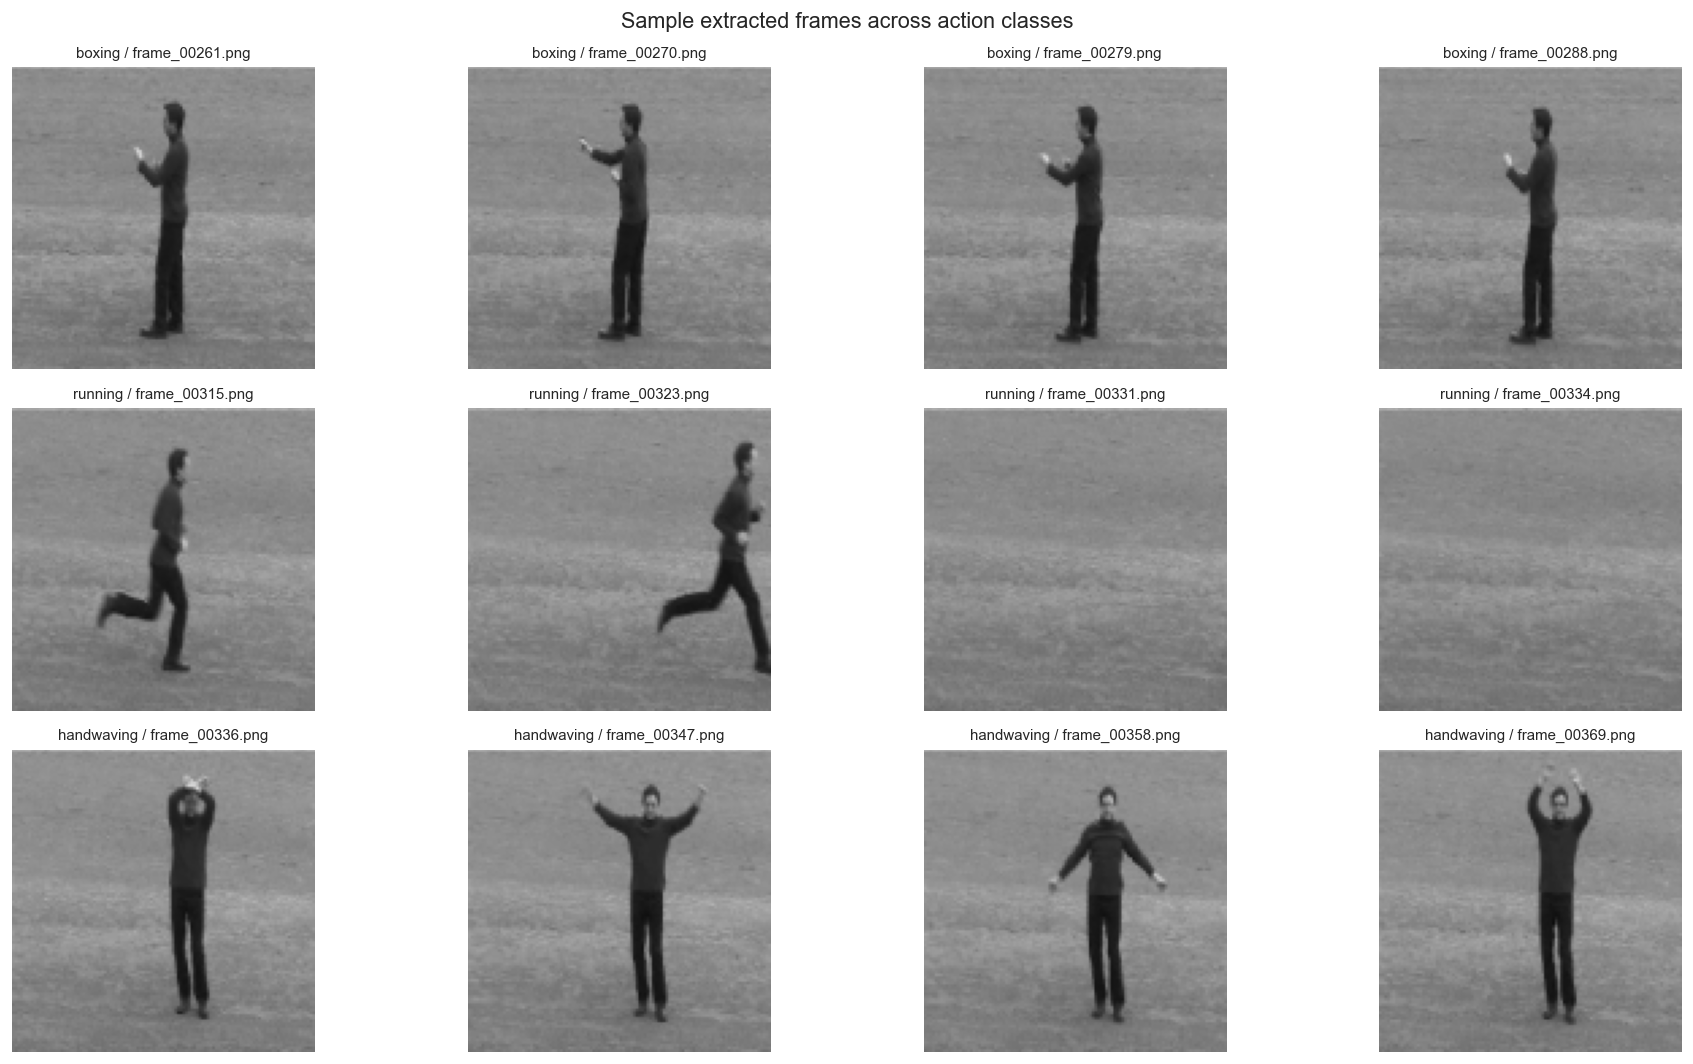

In [5]:
t0 = time.time()
new_frames = extract_frames_for_selected(selected_avis, raw_root, frames_root, config.resize)
elapsed = time.time() - t0
print(f"Prepared frames for {len(selected_avis)} videos in {elapsed:.1f}s ({new_frames} new PNG files written).")


def find_active_frame_index(frame_paths, start_ratio=0.25):
    """Find a frame where the person is visible by picking the highest-variance frame past the intro."""
    search_start = int(len(frame_paths) * start_ratio)
    best_idx, best_var = search_start, 0.0
    for i in range(search_start, len(frame_paths), max(len(frame_paths) // 20, 1)):
        frame = cv2.imread(str(frame_paths[i]), cv2.IMREAD_GRAYSCALE)
        var = float(frame.var()) if frame is not None else 0.0
        if var > best_var:
            best_var = var
            best_idx = i
    return best_idx


fig, axes = plt.subplots(len(NOTEBOOK_SAMPLE_CLASSES), 4, figsize=(16, 3 * len(NOTEBOOK_SAMPLE_CLASSES)))
for row, class_name in enumerate(NOTEBOOK_SAMPLE_CLASSES):
    video_dir = first_available_video_dir(frames_root, class_name)
    frame_paths = sorted(video_dir.glob("frame_*.png"))
    active_idx = find_active_frame_index(frame_paths)
    # Show 4 frames tightly clustered around the active frame (small step)
    step = max(len(frame_paths) // 40, 2)
    anchor = max(active_idx - step, 0)
    for col in range(4):
        index = min(anchor + col * step, len(frame_paths) - 1)
        frame = cv2.cvtColor(cv2.imread(str(frame_paths[index])), cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(frame)
        axes[row, col].set_title(f"{class_name} / {frame_paths[index].name}", fontsize=9)
        axes[row, col].axis("off")

fig.suptitle("Sample extracted frames across action classes", fontsize=13)
fig.tight_layout()
display(fig)
plt.close(fig)

## 5. Preprocessing: Dense Optical Flow

For every consecutive frame pair in the selected subset, the notebook computes dense Farneback optical flow and stores it as `flow_XXXXX.npy` with shape `(H, W, 2)`.

This is still the most expensive preprocessing step, but reruns stay fast because cached flow files are skipped.

Optical flow: 100%|██████████| 599/599 [00:03<00:00, 199.34video/s]


Prepared optical flow for 599 videos in 3.0s (0 new .npy files written).


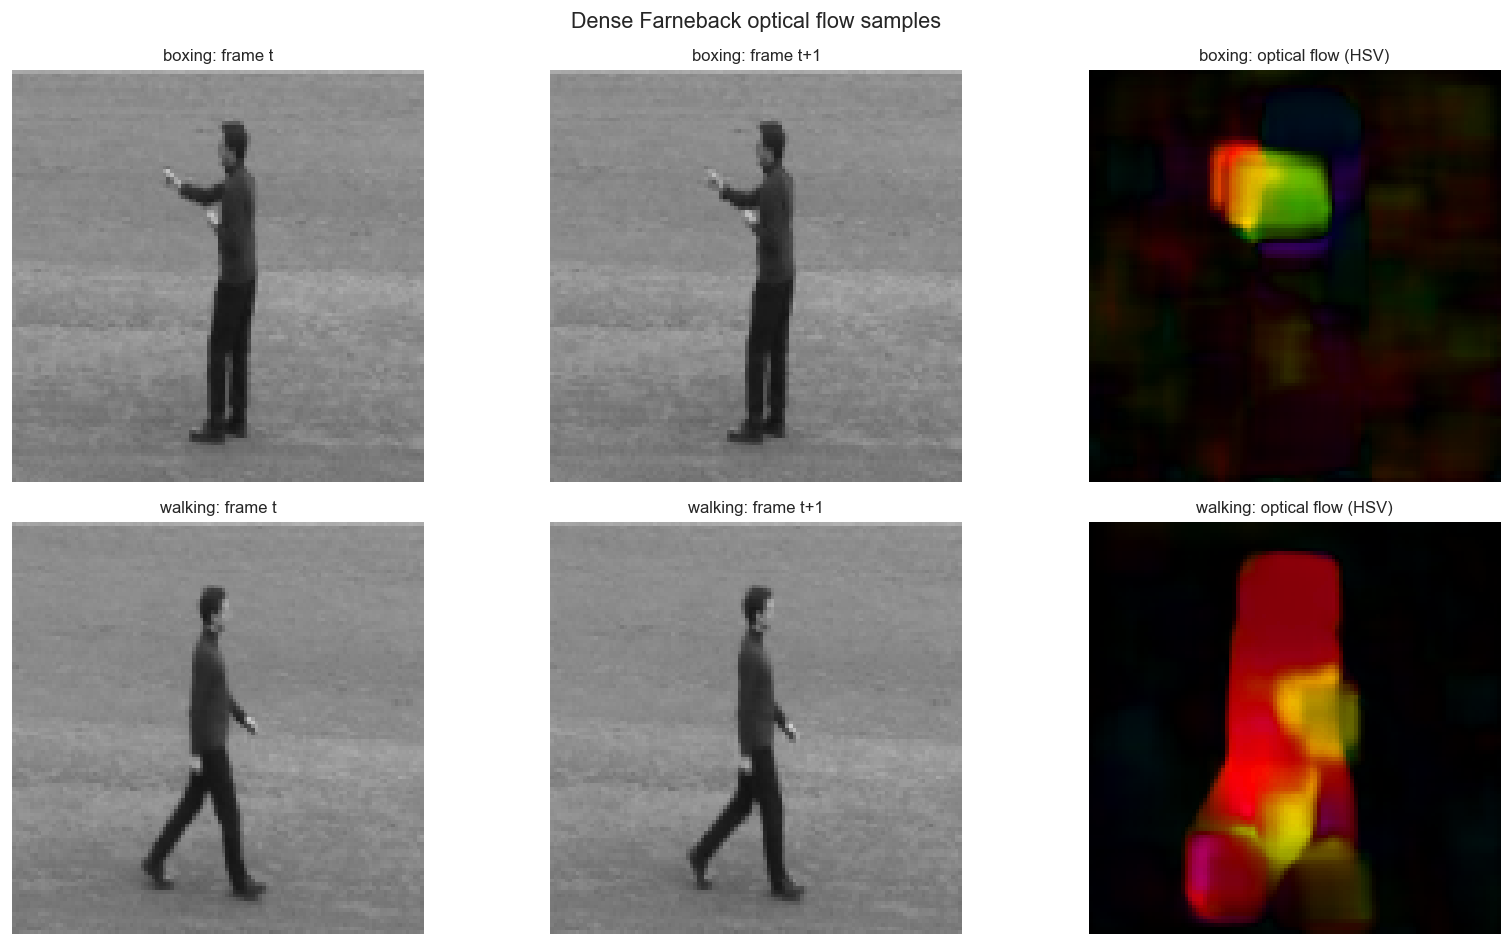

In [6]:
t0 = time.time()
new_flow_files = compute_flow_for_selected(selected_avis, raw_root, frames_root, flow_root)
elapsed = time.time() - t0
print(f"Prepared optical flow for {len(selected_avis)} videos in {elapsed:.1f}s ({new_flow_files} new .npy files written).")

fig, axes = plt.subplots(len(NOTEBOOK_SAMPLE_FLOW_CLASSES), 3, figsize=(14, 4 * len(NOTEBOOK_SAMPLE_FLOW_CLASSES)))
for row, class_name in enumerate(NOTEBOOK_SAMPLE_FLOW_CLASSES):
    video_dir = first_available_video_dir(frames_root, class_name)
    flow_dir = flow_root / class_name / video_dir.name
    frame_paths = sorted(video_dir.glob("frame_*.png"))
    flow_paths = sorted(flow_dir.glob("flow_*.npy"))
    # Pick a flow frame where the person is actually visible (high variance = motion)
    active_idx = find_active_frame_index(frame_paths)
    # Clamp to valid flow range (flow has one fewer entry than frames)
    active_idx = min(active_idx, len(flow_paths) - 1)

    frame_a = cv2.cvtColor(cv2.imread(str(frame_paths[active_idx])), cv2.COLOR_BGR2RGB)
    frame_b = cv2.cvtColor(cv2.imread(str(frame_paths[active_idx + 1])), cv2.COLOR_BGR2RGB)
    flow_hsv = visualize_flow(np.load(flow_paths[active_idx]))

    for col, (image, title) in enumerate(
        zip(
            [frame_a, frame_b, flow_hsv],
            [f"{class_name}: frame t", f"{class_name}: frame t+1", f"{class_name}: optical flow (HSV)"],
            strict=True,
        )
    ):
        axes[row, col].imshow(image)
        axes[row, col].set_title(title, fontsize=10)
        axes[row, col].axis("off")

fig.suptitle("Dense Farneback optical flow samples", fontsize=13)
fig.tight_layout()
display(fig)
plt.close(fig)

## 6. Dataset Split Summary

The KTH protocol here uses a person-based split: persons 1-12 for training, 13-16 for validation, and 17-25 for testing. The notebook keeps that protocol intact even when it uses a smaller CPU subset.

Below we summarize the prepared frame and flow directories that will feed the three experiments.



In [7]:
flow_train_dirs, flow_train_labels, flow_val_dirs, flow_val_labels, flow_test_dirs, flow_test_labels = get_train_val_test_split(config.data_root, mode="flow")
frame_train_dirs, frame_train_labels, frame_val_dirs, frame_val_labels, frame_test_dirs, frame_test_labels = get_train_val_test_split(config.data_root, mode="rgb")

if not flow_train_dirs or not flow_val_dirs or not flow_test_dirs:
    raise RuntimeError("Flow split is empty. Check preprocessing output under data/kth/flow.")
if not frame_train_dirs or not frame_val_dirs or not frame_test_dirs:
    raise RuntimeError("RGB split is empty. Check preprocessing output under data/kth/frames.")


def split_summary(train_labels, val_labels, test_labels, class_names):
    rows = []
    for label, class_name in enumerate(class_names):
        rows.append(
            {
                "class": class_name,
                "train": sum(1 for item in train_labels if item == label),
                "val": sum(1 for item in val_labels if item == label),
                "test": sum(1 for item in test_labels if item == label),
            }
        )
    return pd.DataFrame(rows)


print("=== Flow dataset split ===")
display(split_summary(flow_train_labels, flow_val_labels, flow_test_labels, config.class_names))
print(f"Flow: {len(flow_train_dirs)} train / {len(flow_val_dirs)} val / {len(flow_test_dirs)} test videos")

print("\n=== RGB dataset split ===")
display(split_summary(frame_train_labels, frame_val_labels, frame_test_labels, config.class_names))
print(f"RGB: {len(frame_train_dirs)} train / {len(frame_val_dirs)} val / {len(frame_test_dirs)} test videos")

=== Flow dataset split ===


,class,train,val,test
0,boxing,48,16,36
1,handclapping,48,15,36
2,handwaving,48,16,36
3,jogging,48,16,36
4,running,48,16,36
5,walking,48,16,36


Flow: 288 train / 95 val / 216 test videos

=== RGB dataset split ===


,class,train,val,test
0,boxing,48,16,36
1,handclapping,48,15,36
2,handwaving,48,16,36
3,jogging,48,16,36
4,running,48,16,36
5,walking,48,16,36


RGB: 288 train / 95 val / 216 test videos


---

## 7. Experiment 1: Optical Flow Model

### Architecture

The flow model is a **ResNet-18** with a modified first convolution layer. Instead of 3 RGB channels, it accepts **20 input channels** (10 flow fields x 2 displacement axes). The pretrained ImageNet conv1 weights are inflated by round-robin replication with energy-preserving scaling:

$$W_{\text{new}}[:, c, :, :] = W_{\text{rgb}}[:, c \bmod 3, :, :] \times \frac{3}{C_{\text{in}}}$$

This initialization lets the flow model start from a reasonable feature space rather than random weights, even though the input modality differs from ImageNet images.

### Hypothesis

Optical flow explicitly encodes **motion**, which is the primary discriminative signal for action recognition on KTH. We expect the flow model to outperform the single-frame appearance baseline and to remain competitive with the stronger temporal appearance baseline.



In [8]:
# Experiment 1: Optical Flow
seed_everything(config.seed)

flow_config = replace(config, mode="flow", output_dir=Path("outputs/flow"))
flow_config.output_dir.mkdir(parents=True, exist_ok=True)

flow_train_ds = FlowClipDataset(flow_train_dirs, flow_train_labels, flow_config, train=True)
flow_val_ds = FlowClipDataset(flow_val_dirs, flow_val_labels, flow_config, train=False)
flow_test_ds = FlowClipDataset(flow_test_dirs, flow_test_labels, flow_config, train=False)

flow_train_loader = build_loader(flow_train_ds, flow_config, shuffle=True)
flow_val_loader = build_loader(flow_val_ds, flow_config, shuffle=False)
flow_test_loader = build_loader(flow_test_ds, flow_config, shuffle=False)

sample, label = flow_train_ds[0]
print(f"Flow input tensor shape: {tuple(sample.shape)} (2 x clip_length channels x H x W)")
print(f"Value range: [{sample.min():.3f}, {sample.max():.3f}]")
print(f"Train: {len(flow_train_ds)} clips | Val: {len(flow_val_ds)} clips | Test: {len(flow_test_ds)} clips")
print(f"DataLoader settings: num_workers={flow_config.num_workers}, pin_memory={flow_config.device == 'cuda'}")

flow_model = build_resnet18_flow(
    num_classes=flow_config.num_classes,
    input_channels=flow_config.input_channels,
    pretrained=flow_config.pretrained_backbone,
)
total_params = sum(parameter.numel() for parameter in flow_model.parameters())
print(f"Flow model parameters: {total_params:,}")


Flow input tensor shape: (20, 224, 224) (2 x clip_length channels x H x W)
Value range: [-0.389, 0.262]
Train: 288 clips | Val: 95 clips | Test: 216 clips
DataLoader settings: num_workers=0, pin_memory=True
Flow model parameters: 11,232,902


### Training

Epoch 1/30 train_loss=1.5396 train_acc=0.3993 val_loss=7.6215 val_acc=0.1684
Epoch 2/30 train_loss=1.1974 train_acc=0.5312 val_loss=1.9580 val_acc=0.3579
Epoch 3/30 train_loss=0.9643 train_acc=0.5382 val_loss=1.1067 val_acc=0.4737
Epoch 4/30 train_loss=0.8515 train_acc=0.5868 val_loss=1.0507 val_acc=0.5263
Epoch 5/30 train_loss=0.7536 train_acc=0.6597 val_loss=0.8407 val_acc=0.5579
Epoch 6/30 train_loss=0.7659 train_acc=0.6597 val_loss=0.7859 val_acc=0.6105
Epoch 7/30 train_loss=0.7268 train_acc=0.6389 val_loss=0.8374 val_acc=0.5368
Epoch 8/30 train_loss=0.7516 train_acc=0.6319 val_loss=0.8289 val_acc=0.6105
Epoch 9/30 train_loss=0.7654 train_acc=0.6424 val_loss=0.9387 val_acc=0.5474
Epoch 10/30 train_loss=0.7028 train_acc=0.6667 val_loss=0.8292 val_acc=0.5895
Epoch 11/30 train_loss=0.6856 train_acc=0.6562 val_loss=0.7657 val_acc=0.6105
Epoch 12/30 train_loss=0.7071 train_acc=0.6806 val_loss=0.7921 val_acc=0.6421
Epoch 13/30 train_loss=0.7139 train_acc=0.6944 val_loss=0.9121 val_acc=0.

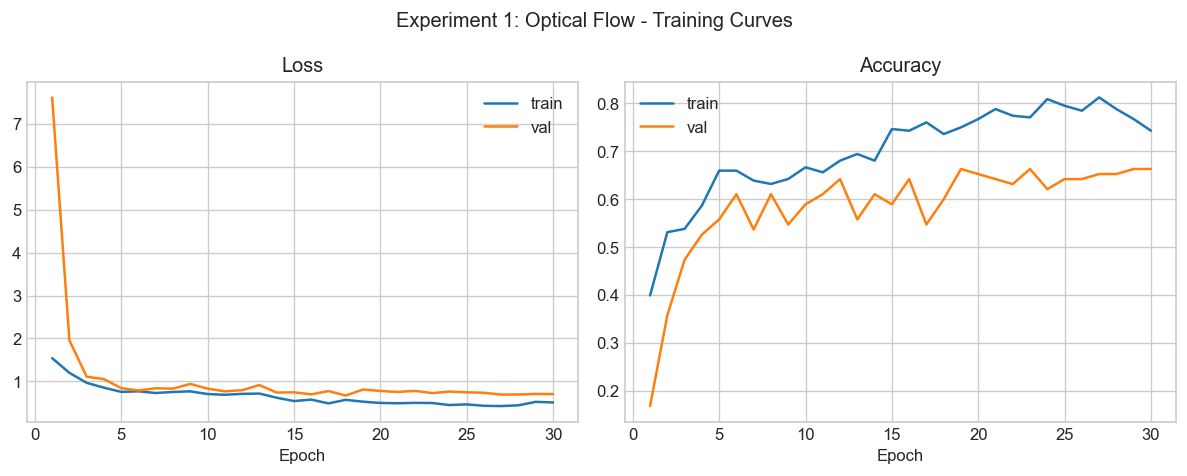

In [9]:
flow_trainer = Trainer(
    model=flow_model,
    train_loader=flow_train_loader,
    val_loader=flow_val_loader,
    config=flow_config,
    device=flow_config.device,
)
flow_history = flow_trainer.train()

fig = plot_training_curves(flow_history, save_path=flow_config.output_dir / "training_curves_flow.png")
fig.suptitle("Experiment 1: Optical Flow - Training Curves", fontsize=12)
fig.tight_layout()
display(fig)
plt.close(fig)


### Evaluation: Confusion Matrix & Per-Class Metrics

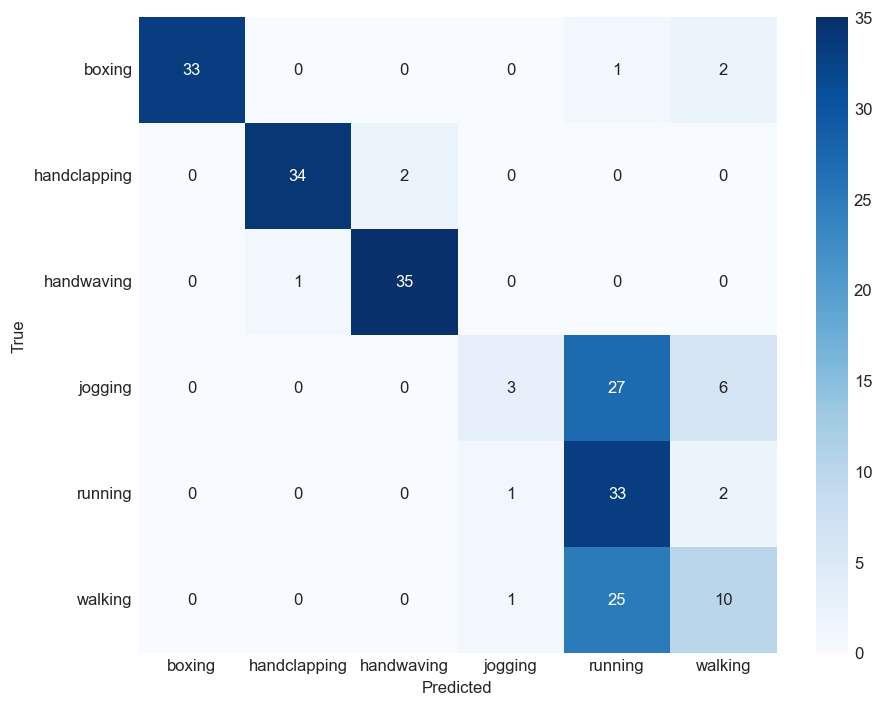

Test accuracy: 0.6852 | Macro F1: 0.6529


,precision,recall,f1-score,support
boxing,1.000,0.917,0.957,36.000
handclapping,0.971,0.944,0.958,36.000
handwaving,0.946,0.972,0.959,36.000
jogging,0.600,0.083,0.146,36.000
running,0.384,0.917,0.541,36.000
walking,0.500,0.278,0.357,36.000
accuracy,0.685,0.685,0.685,0.685
macro avg,0.734,0.685,0.653,216.000
weighted avg,0.734,0.685,0.653,216.000



Best flow checkpoint saved at epoch 30


In [10]:
# Reload best flow checkpoint for evaluation
flow_ckpt_path = flow_config.output_dir / "best_flow.pt"
flow_ckpt = torch.load(flow_ckpt_path, map_location=flow_config.device, weights_only=False)

flow_best = build_resnet18_flow(
    num_classes=flow_config.num_classes,
    input_channels=flow_config.input_channels,
    pretrained=False,
)
flow_best.load_state_dict(flow_ckpt["model_state_dict"])
flow_best.to(flow_config.device)

flow_metrics = evaluate_model_inline(
    model=flow_best,
    data_loader=flow_test_loader,
    class_names=flow_config.class_names,
    device=flow_config.device,
    output_dir=flow_config.output_dir,
    mode="flow",
)
print(f"\nBest flow checkpoint saved at epoch {flow_ckpt['epoch']}")


---

## 8. Experiment 2: Single-Frame Appearance Baseline

### Architecture

The single-frame appearance model is a standard ResNet-18 with a replaced final FC layer for 6-class classification. Each input is the center frame of a temporal clip, normalized with ImageNet statistics.

KTH is effectively grayscale even though the files are stored as RGB images, so this is best interpreted as a **single-frame appearance baseline** rather than a color-rich RGB model.

### Hypothesis

A single frame captures pose and silhouette but not explicit motion. This baseline tests how far static appearance alone can go before temporal information is added back in.



In [11]:
# Experiment 2: Single-Frame Appearance Baseline
seed_everything(config.seed)

appearance_single_config = replace(config, mode="appearance_single", output_dir=Path("outputs/appearance_single"))
appearance_single_config.output_dir.mkdir(parents=True, exist_ok=True)

appearance_single_train_ds = RGBClipDataset(frame_train_dirs, frame_train_labels, appearance_single_config, train=True)
appearance_single_val_ds = RGBClipDataset(frame_val_dirs, frame_val_labels, appearance_single_config, train=False)
appearance_single_test_ds = RGBClipDataset(frame_test_dirs, frame_test_labels, appearance_single_config, train=False)

appearance_single_train_loader = build_loader(appearance_single_train_ds, appearance_single_config, shuffle=True)
appearance_single_val_loader = build_loader(appearance_single_val_ds, appearance_single_config, shuffle=False)
appearance_single_test_loader = build_loader(appearance_single_test_ds, appearance_single_config, shuffle=False)

sample, label = appearance_single_train_ds[0]
print(f"Single-frame appearance input tensor shape: {tuple(sample.shape)}")
print(f"Value range: [{sample.min():.3f}, {sample.max():.3f}]")
print(f"Train: {len(appearance_single_train_ds)} clips | Val: {len(appearance_single_val_ds)} clips | Test: {len(appearance_single_test_ds)} clips")

appearance_single_model = build_resnet18_flow(
    num_classes=appearance_single_config.num_classes,
    input_channels=appearance_single_config.input_channels,
    pretrained=appearance_single_config.pretrained_backbone,
)
total_params = sum(parameter.numel() for parameter in appearance_single_model.parameters())
print(f"Single-frame appearance model parameters: {total_params:,}")


Single-frame appearance input tensor shape: (3, 224, 224)
Value range: [-1.775, 1.350]
Train: 288 clips | Val: 95 clips | Test: 216 clips
Single-frame appearance model parameters: 11,179,590


### Training

Epoch 1/30 train_loss=1.7098 train_acc=0.3021 val_loss=4.9626 val_acc=0.3158
Epoch 2/30 train_loss=1.2101 train_acc=0.4097 val_loss=1.3804 val_acc=0.3684
Epoch 3/30 train_loss=1.0493 train_acc=0.4514 val_loss=1.3388 val_acc=0.3158
Epoch 4/30 train_loss=1.0275 train_acc=0.5208 val_loss=1.4895 val_acc=0.3368
Epoch 5/30 train_loss=0.9135 train_acc=0.5660 val_loss=1.6598 val_acc=0.4211
Epoch 6/30 train_loss=0.9078 train_acc=0.5347 val_loss=1.7398 val_acc=0.4000
Epoch 7/30 train_loss=0.8579 train_acc=0.5729 val_loss=1.2869 val_acc=0.4737
Epoch 8/30 train_loss=0.8122 train_acc=0.5833 val_loss=1.3061 val_acc=0.3684
Epoch 9/30 train_loss=0.8672 train_acc=0.5764 val_loss=1.1483 val_acc=0.4211
Epoch 10/30 train_loss=0.7579 train_acc=0.6146 val_loss=1.1631 val_acc=0.4211
Epoch 11/30 train_loss=0.7951 train_acc=0.6319 val_loss=1.0894 val_acc=0.4526
Epoch 12/30 train_loss=0.7268 train_acc=0.6389 val_loss=1.4043 val_acc=0.4316
Epoch 13/30 train_loss=0.6997 train_acc=0.6597 val_loss=1.2299 val_acc=0.

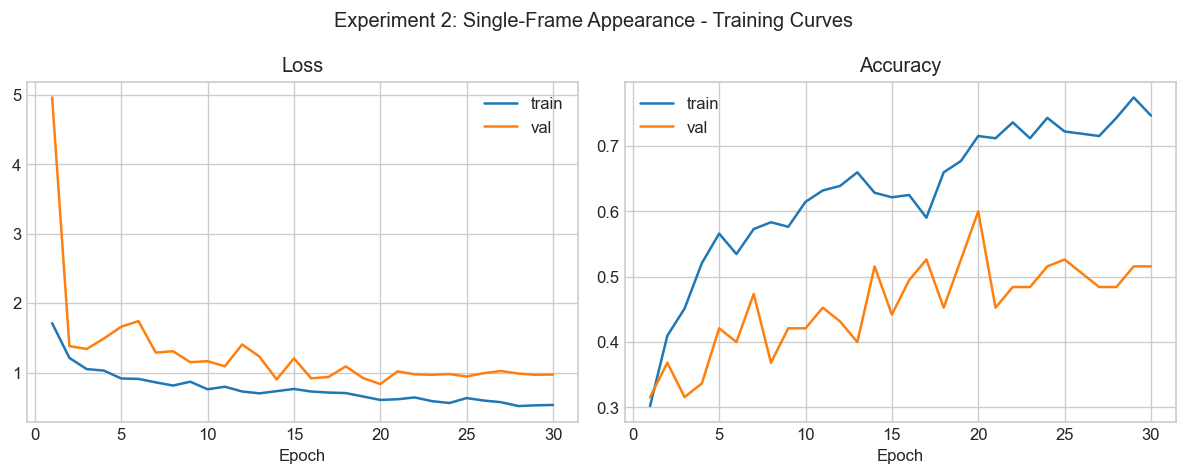

In [12]:
appearance_single_trainer = Trainer(
    model=appearance_single_model,
    train_loader=appearance_single_train_loader,
    val_loader=appearance_single_val_loader,
    config=appearance_single_config,
    device=appearance_single_config.device,
)
appearance_single_history = appearance_single_trainer.train()

fig = plot_training_curves(
    appearance_single_history,
    save_path=appearance_single_config.output_dir / "training_curves_appearance_single.png",
)
fig.suptitle("Experiment 2: Single-Frame Appearance - Training Curves", fontsize=12)
fig.tight_layout()
display(fig)
plt.close(fig)


### Evaluation: Confusion Matrix & Per-Class Metrics

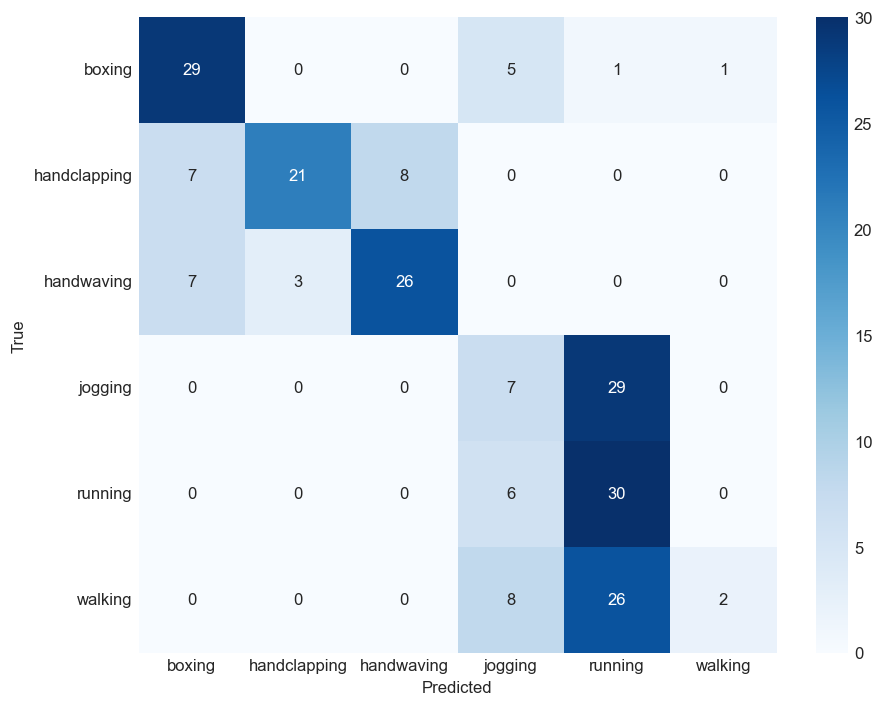

Test accuracy: 0.5324 | Macro F1: 0.4995


,precision,recall,f1-score,support
boxing,0.674,0.806,0.734,36.000
handclapping,0.875,0.583,0.700,36.000
handwaving,0.765,0.722,0.743,36.000
jogging,0.269,0.194,0.226,36.000
running,0.349,0.833,0.492,36.000
walking,0.667,0.056,0.103,36.000
accuracy,0.532,0.532,0.532,0.532
macro avg,0.600,0.532,0.500,216.000
weighted avg,0.600,0.532,0.500,216.000



Best single-frame appearance checkpoint saved at epoch 20


In [13]:
# Reload best single-frame appearance checkpoint for evaluation
appearance_single_ckpt_path = appearance_single_config.output_dir / "best_appearance_single.pt"
appearance_single_ckpt = torch.load(appearance_single_ckpt_path, map_location=appearance_single_config.device, weights_only=False)

appearance_single_best = build_resnet18_flow(
    num_classes=appearance_single_config.num_classes,
    input_channels=appearance_single_config.input_channels,
    pretrained=False,
)
appearance_single_best.load_state_dict(appearance_single_ckpt["model_state_dict"])
appearance_single_best.to(appearance_single_config.device)

appearance_single_metrics = evaluate_model_inline(
    model=appearance_single_best,
    data_loader=appearance_single_test_loader,
    class_names=appearance_single_config.class_names,
    device=appearance_single_config.device,
    output_dir=appearance_single_config.output_dir,
    mode="appearance_single",
)
print(f"\nBest single-frame appearance checkpoint saved at epoch {appearance_single_ckpt['epoch']}")


---

## 9. Experiment 3: Temporal Appearance Baseline

### Architecture

The temporal appearance model uses the same ResNet-18 backbone, but its first convolution is expanded to accept **10 grayscale frames** stacked across time. This keeps the backbone simple while giving the appearance pathway access to temporal structure instead of only a single image.

### Hypothesis

If the gap between optical flow and the single-frame baseline mostly comes from temporal context, this model should close part of that gap while still relying on appearance rather than explicit motion vectors.



In [14]:
# Experiment 3: Temporal Appearance Baseline
seed_everything(config.seed)

appearance_temporal_config = replace(config, mode="appearance_temporal", output_dir=Path("outputs/appearance_temporal"))
appearance_temporal_config.output_dir.mkdir(parents=True, exist_ok=True)

appearance_temporal_train_ds = TemporalAppearanceClipDataset(frame_train_dirs, frame_train_labels, appearance_temporal_config, train=True)
appearance_temporal_val_ds = TemporalAppearanceClipDataset(frame_val_dirs, frame_val_labels, appearance_temporal_config, train=False)
appearance_temporal_test_ds = TemporalAppearanceClipDataset(frame_test_dirs, frame_test_labels, appearance_temporal_config, train=False)

appearance_temporal_train_loader = build_loader(appearance_temporal_train_ds, appearance_temporal_config, shuffle=True)
appearance_temporal_val_loader = build_loader(appearance_temporal_val_ds, appearance_temporal_config, shuffle=False)
appearance_temporal_test_loader = build_loader(appearance_temporal_test_ds, appearance_temporal_config, shuffle=False)

sample, label = appearance_temporal_train_ds[0]
print(f"Temporal appearance input tensor shape: {tuple(sample.shape)}")
print(f"Value range: [{sample.min():.3f}, {sample.max():.3f}]")
print(f"Train: {len(appearance_temporal_train_ds)} clips | Val: {len(appearance_temporal_val_ds)} clips | Test: {len(appearance_temporal_test_ds)} clips")

appearance_temporal_model = build_resnet18_flow(
    num_classes=appearance_temporal_config.num_classes,
    input_channels=appearance_temporal_config.input_channels,
    pretrained=appearance_temporal_config.pretrained_backbone,
)
total_params = sum(parameter.numel() for parameter in appearance_temporal_model.parameters())
print(f"Temporal appearance model parameters: {total_params:,}")


Temporal appearance input tensor shape: (10, 224, 224)
Value range: [-1.686, 1.278]
Train: 288 clips | Val: 95 clips | Test: 216 clips
Temporal appearance model parameters: 11,201,542


### Training



Epoch 1/30 train_loss=1.3118 train_acc=0.4306 val_loss=5.9029 val_acc=0.2316
Epoch 2/30 train_loss=0.8710 train_acc=0.5938 val_loss=0.7688 val_acc=0.5895
Epoch 3/30 train_loss=0.8510 train_acc=0.5729 val_loss=0.7878 val_acc=0.6211
Epoch 4/30 train_loss=0.7527 train_acc=0.6285 val_loss=0.6904 val_acc=0.6316
Epoch 5/30 train_loss=0.7447 train_acc=0.6389 val_loss=1.2139 val_acc=0.4211
Epoch 6/30 train_loss=0.7273 train_acc=0.6354 val_loss=1.4453 val_acc=0.5158
Epoch 7/30 train_loss=0.7025 train_acc=0.6285 val_loss=0.8275 val_acc=0.5263
Epoch 8/30 train_loss=0.7196 train_acc=0.6771 val_loss=1.0556 val_acc=0.5579
Epoch 9/30 train_loss=0.6108 train_acc=0.6875 val_loss=0.6722 val_acc=0.6842
Epoch 10/30 train_loss=0.6483 train_acc=0.6701 val_loss=0.7667 val_acc=0.6105
Epoch 11/30 train_loss=0.5942 train_acc=0.6736 val_loss=1.0918 val_acc=0.5368
Epoch 12/30 train_loss=0.6589 train_acc=0.7153 val_loss=0.6559 val_acc=0.6211
Epoch 13/30 train_loss=0.7045 train_acc=0.6319 val_loss=0.8217 val_acc=0.

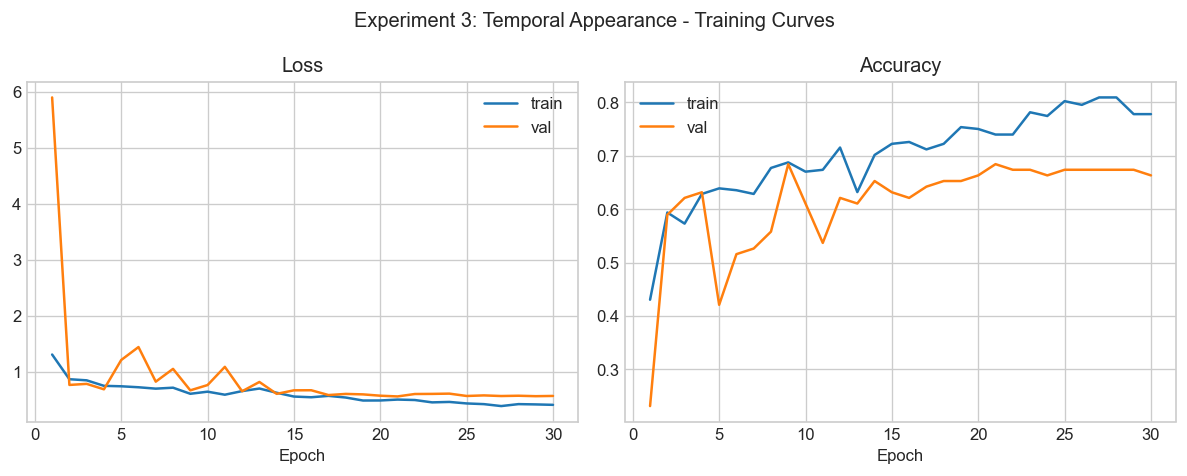

In [15]:
appearance_temporal_trainer = Trainer(
    model=appearance_temporal_model,
    train_loader=appearance_temporal_train_loader,
    val_loader=appearance_temporal_val_loader,
    config=appearance_temporal_config,
    device=appearance_temporal_config.device,
)
appearance_temporal_history = appearance_temporal_trainer.train()

fig = plot_training_curves(
    appearance_temporal_history,
    save_path=appearance_temporal_config.output_dir / "training_curves_appearance_temporal.png",
)
fig.suptitle("Experiment 3: Temporal Appearance - Training Curves", fontsize=12)
fig.tight_layout()
display(fig)
plt.close(fig)


### Evaluation: Confusion Matrix & Per-Class Metrics



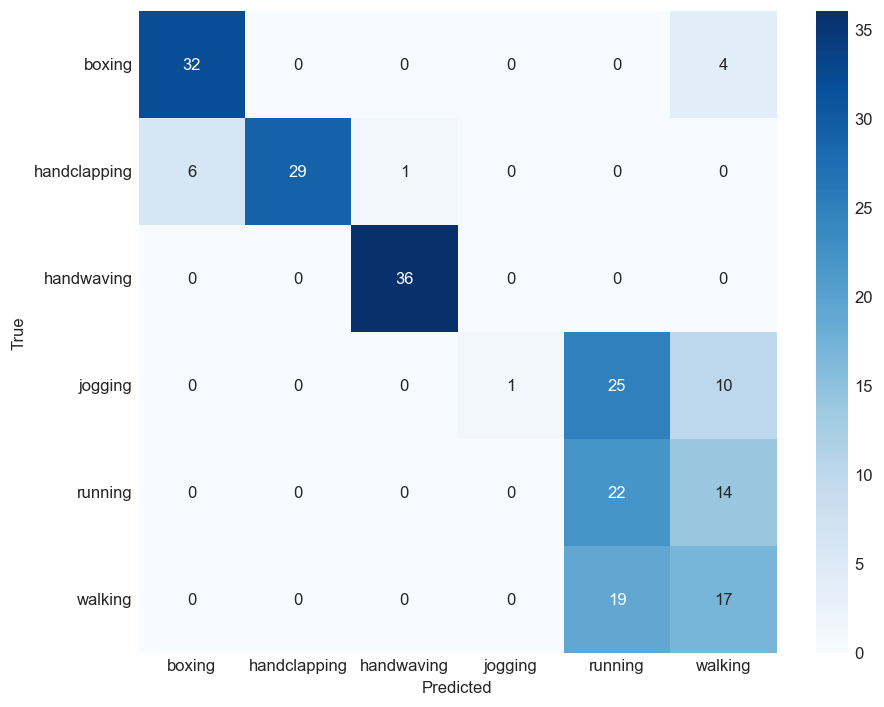

Test accuracy: 0.6343 | Macro F1: 0.6081


,precision,recall,f1-score,support
boxing,0.842,0.889,0.865,36.000
handclapping,1.000,0.806,0.892,36.000
handwaving,0.973,1.000,0.986,36.000
jogging,1.000,0.028,0.054,36.000
running,0.333,0.611,0.431,36.000
walking,0.378,0.472,0.420,36.000
accuracy,0.634,0.634,0.634,0.634
macro avg,0.754,0.634,0.608,216.000
weighted avg,0.754,0.634,0.608,216.000



Best temporal appearance checkpoint saved at epoch 21


In [16]:
# Reload best temporal appearance checkpoint for evaluation
appearance_temporal_ckpt_path = appearance_temporal_config.output_dir / "best_appearance_temporal.pt"
appearance_temporal_ckpt = torch.load(appearance_temporal_ckpt_path, map_location=appearance_temporal_config.device, weights_only=False)

appearance_temporal_best = build_resnet18_flow(
    num_classes=appearance_temporal_config.num_classes,
    input_channels=appearance_temporal_config.input_channels,
    pretrained=False,
)
appearance_temporal_best.load_state_dict(appearance_temporal_ckpt["model_state_dict"])
appearance_temporal_best.to(appearance_temporal_config.device)

appearance_temporal_metrics = evaluate_model_inline(
    model=appearance_temporal_best,
    data_loader=appearance_temporal_test_loader,
    class_names=appearance_temporal_config.class_names,
    device=appearance_temporal_config.device,
    output_dir=appearance_temporal_config.output_dir,
    mode="appearance_temporal",
)
print(f"\nBest temporal appearance checkpoint saved at epoch {appearance_temporal_ckpt['epoch']}")


---

## 10. Comparison: Motion vs Appearance

This section brings together the results from all three experiments for direct comparison. We compare:

1. Overall metrics and best validation epochs.
2. Per-class F1 scores.
3. Confusion matrices side by side.
4. Training dynamics across the three setups.



=== Experiment Comparison ===


,Metric,Optical Flow,Single-Frame Appearance,Temporal Appearance
0,Best val epoch,30,20,21
1,Accuracy,0.6852,0.5324,0.6343
2,Macro F1,0.6529,0.4995,0.6081
3,Weighted F1,0.6529,0.4995,0.6081



=== Per-Class F1 Scores ===


,Class,Optical Flow F1,Single-Frame F1,Temporal Appearance F1
0,boxing,0.957000,0.734000,0.865000
1,handclapping,0.958000,0.700000,0.892000
2,handwaving,0.959000,0.743000,0.986000
3,jogging,0.146000,0.226000,0.054000
4,running,0.541000,0.492000,0.431000
5,walking,0.357000,0.103000,0.420000


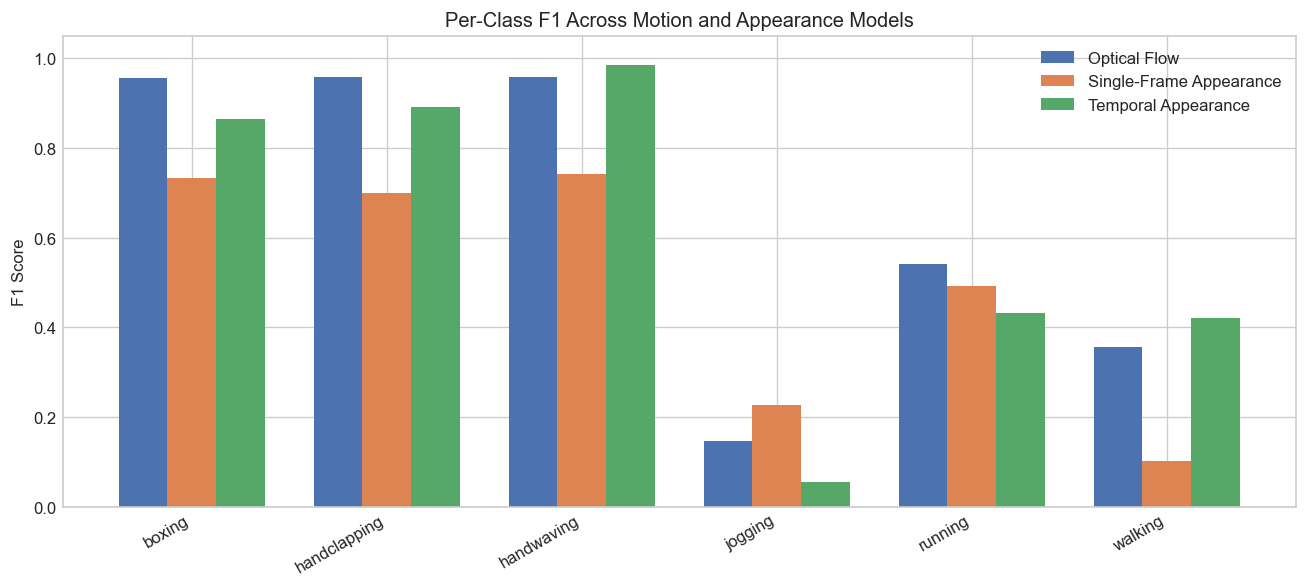

In [17]:
# Summary tables
comparison = pd.DataFrame(
    {
        "Metric": ["Best val epoch", "Accuracy", "Macro F1", "Weighted F1"],
        "Optical Flow": [str(flow_ckpt["epoch"]), f"{flow_metrics['accuracy']:.4f}", f"{flow_metrics['macro_f1']:.4f}", f"{flow_metrics['weighted_f1']:.4f}"],
        "Single-Frame Appearance": [str(appearance_single_ckpt["epoch"]), f"{appearance_single_metrics['accuracy']:.4f}", f"{appearance_single_metrics['macro_f1']:.4f}", f"{appearance_single_metrics['weighted_f1']:.4f}"],
        "Temporal Appearance": [str(appearance_temporal_ckpt["epoch"]), f"{appearance_temporal_metrics['accuracy']:.4f}", f"{appearance_temporal_metrics['macro_f1']:.4f}", f"{appearance_temporal_metrics['weighted_f1']:.4f}"],
    }
)
print("=== Experiment Comparison ===")
display(comparison.style.set_caption("Overall metrics across motion and appearance models"))

per_class = pd.DataFrame(
    {
        "Class": list(config.class_names),
        "Optical Flow F1": [flow_metrics["classification_report"][class_name]["f1-score"] for class_name in config.class_names],
        "Single-Frame F1": [appearance_single_metrics["classification_report"][class_name]["f1-score"] for class_name in config.class_names],
        "Temporal Appearance F1": [appearance_temporal_metrics["classification_report"][class_name]["f1-score"] for class_name in config.class_names],
    }
).round(3)
print("\n=== Per-Class F1 Scores ===")
display(per_class.style.set_caption("Per-class F1 across all three experiments"))

x = np.arange(len(config.class_names))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, per_class["Optical Flow F1"], width, label="Optical Flow", color="#4C72B0")
ax.bar(x, per_class["Single-Frame F1"], width, label="Single-Frame Appearance", color="#DD8452")
ax.bar(x + width, per_class["Temporal Appearance F1"], width, label="Temporal Appearance", color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(config.class_names, rotation=30, ha="right")
ax.set_ylabel("F1 Score")
ax.set_title("Per-Class F1 Across Motion and Appearance Models")
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
display(fig)
plt.close(fig)



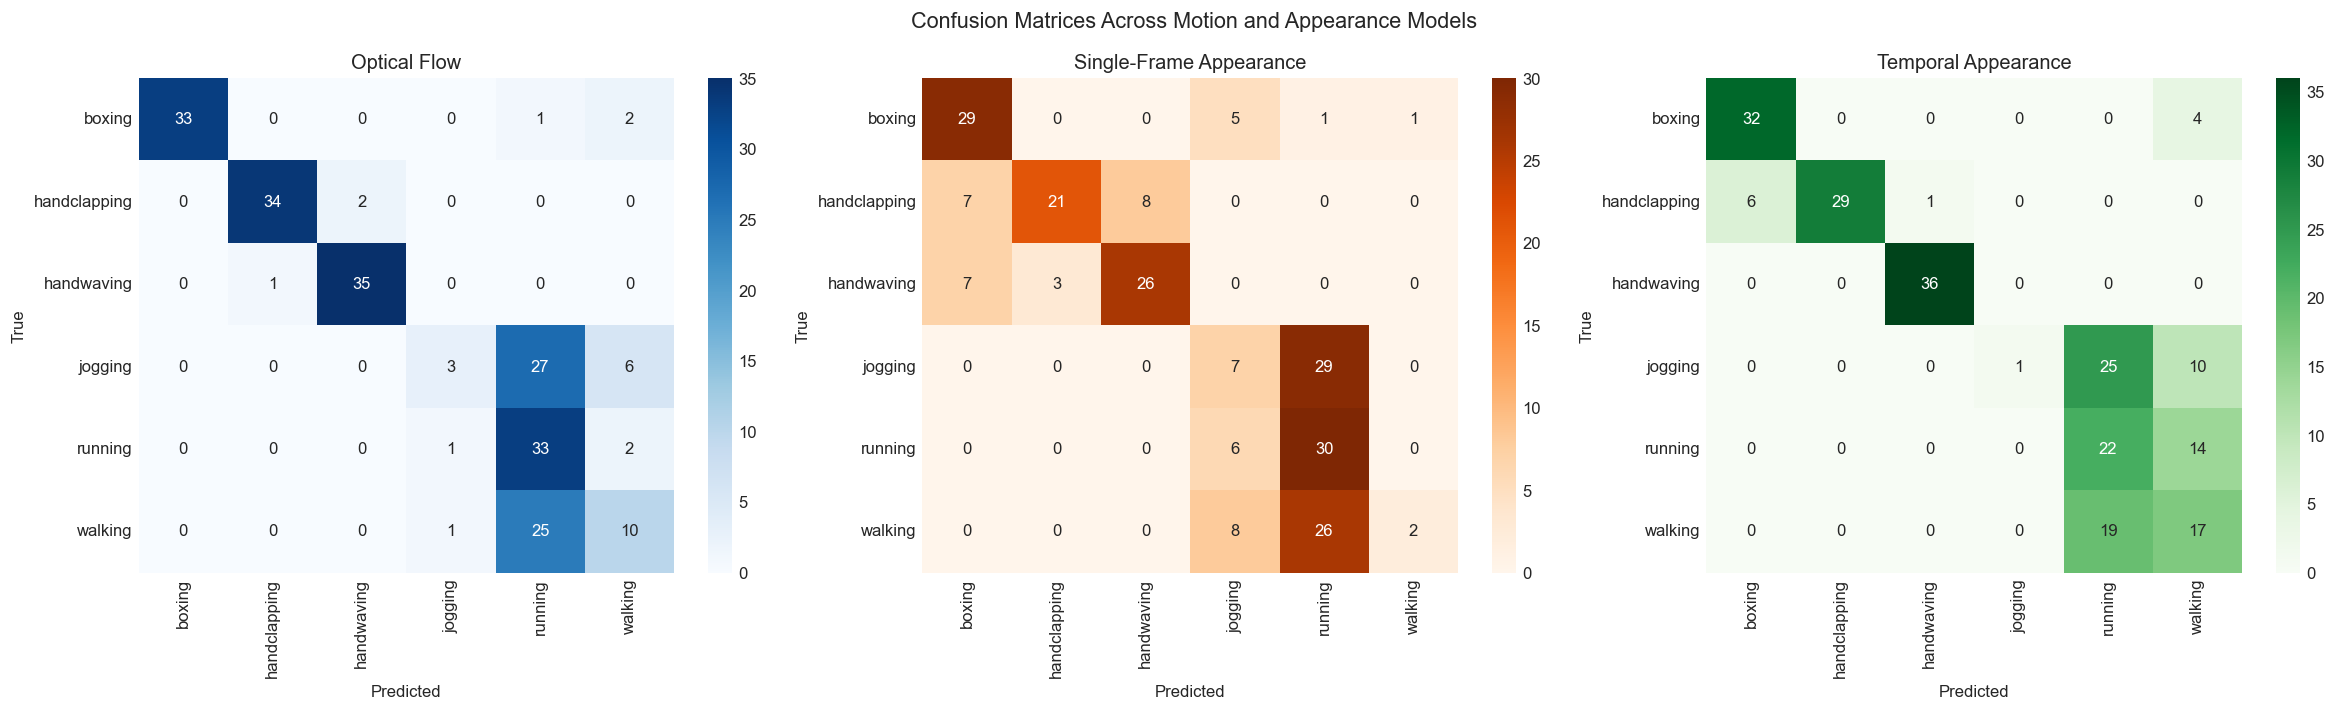

In [18]:
# Side-by-side confusion matrices
import seaborn as sns

flow_cm = np.array(flow_metrics["confusion_matrix"])
appearance_single_cm = np.array(appearance_single_metrics["confusion_matrix"])
appearance_temporal_cm = np.array(appearance_temporal_metrics["confusion_matrix"])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(flow_cm, annot=True, fmt="d", cmap="Blues", xticklabels=config.class_names, yticklabels=config.class_names, ax=axes[0])
axes[0].set_title("Optical Flow")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
sns.heatmap(appearance_single_cm, annot=True, fmt="d", cmap="Oranges", xticklabels=config.class_names, yticklabels=config.class_names, ax=axes[1])
axes[1].set_title("Single-Frame Appearance")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
sns.heatmap(appearance_temporal_cm, annot=True, fmt="d", cmap="Greens", xticklabels=config.class_names, yticklabels=config.class_names, ax=axes[2])
axes[2].set_title("Temporal Appearance")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
fig.suptitle("Confusion Matrices Across Motion and Appearance Models", fontsize=13)
fig.tight_layout()
display(fig)
plt.close(fig)



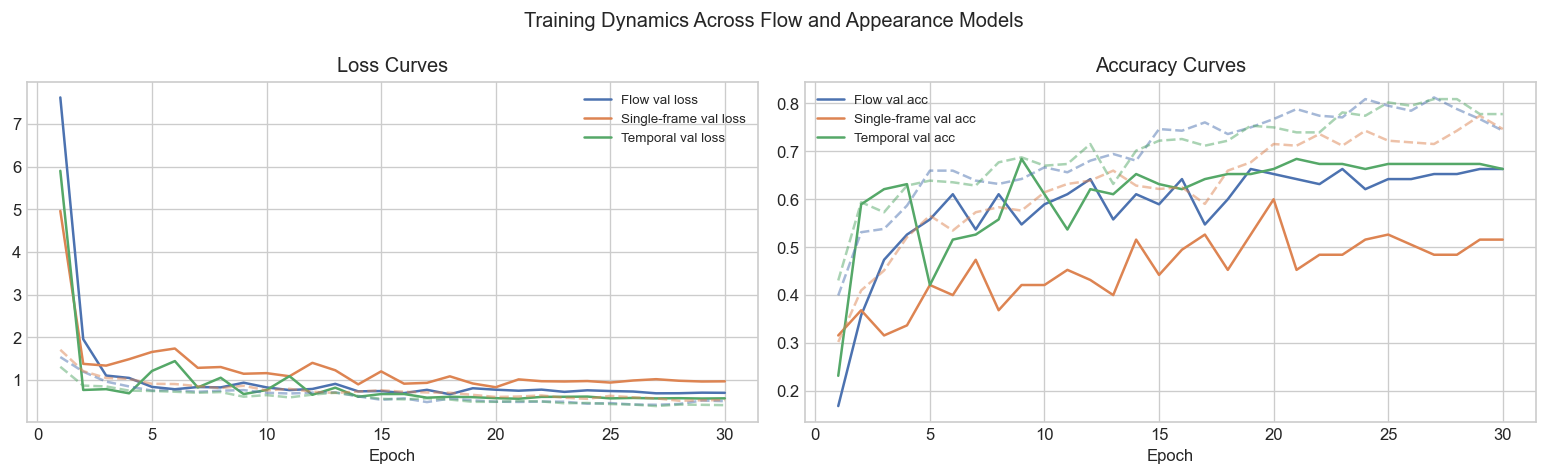

In [19]:
# Training dynamics comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(1, len(flow_history["val_loss"]) + 1), flow_history["val_loss"], label="Flow val loss", color="#4C72B0")
axes[0].plot(range(1, len(appearance_single_history["val_loss"]) + 1), appearance_single_history["val_loss"], label="Single-frame val loss", color="#DD8452")
axes[0].plot(range(1, len(appearance_temporal_history["val_loss"]) + 1), appearance_temporal_history["val_loss"], label="Temporal val loss", color="#55A868")
axes[0].plot(range(1, len(flow_history["train_loss"]) + 1), flow_history["train_loss"], "--", alpha=0.5, color="#4C72B0")
axes[0].plot(range(1, len(appearance_single_history["train_loss"]) + 1), appearance_single_history["train_loss"], "--", alpha=0.5, color="#DD8452")
axes[0].plot(range(1, len(appearance_temporal_history["train_loss"]) + 1), appearance_temporal_history["train_loss"], "--", alpha=0.5, color="#55A868")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=8)
axes[1].plot(range(1, len(flow_history["val_acc"]) + 1), flow_history["val_acc"], label="Flow val acc", color="#4C72B0")
axes[1].plot(range(1, len(appearance_single_history["val_acc"]) + 1), appearance_single_history["val_acc"], label="Single-frame val acc", color="#DD8452")
axes[1].plot(range(1, len(appearance_temporal_history["val_acc"]) + 1), appearance_temporal_history["val_acc"], label="Temporal val acc", color="#55A868")
axes[1].plot(range(1, len(flow_history["train_acc"]) + 1), flow_history["train_acc"], "--", alpha=0.5, color="#4C72B0")
axes[1].plot(range(1, len(appearance_single_history["train_acc"]) + 1), appearance_single_history["train_acc"], "--", alpha=0.5, color="#DD8452")
axes[1].plot(range(1, len(appearance_temporal_history["train_acc"]) + 1), appearance_temporal_history["train_acc"], "--", alpha=0.5, color="#55A868")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
fig.suptitle("Training Dynamics Across Flow and Appearance Models", fontsize=12)
fig.tight_layout()
display(fig)
plt.close(fig)



In [20]:
# Save combined comparison JSON
comparison_payload = {
    "flow": {"best_epoch": int(flow_ckpt["epoch"]), "accuracy": flow_metrics["accuracy"], "macro_f1": flow_metrics["macro_f1"], "weighted_f1": flow_metrics["weighted_f1"]},
    "appearance_single": {"best_epoch": int(appearance_single_ckpt["epoch"]), "accuracy": appearance_single_metrics["accuracy"], "macro_f1": appearance_single_metrics["macro_f1"], "weighted_f1": appearance_single_metrics["weighted_f1"]},
    "appearance_temporal": {"best_epoch": int(appearance_temporal_ckpt["epoch"]), "accuracy": appearance_temporal_metrics["accuracy"], "macro_f1": appearance_temporal_metrics["macro_f1"], "weighted_f1": appearance_temporal_metrics["weighted_f1"]},
    "per_class_f1": {class_name: {"flow": flow_metrics["classification_report"][class_name]["f1-score"], "appearance_single": appearance_single_metrics["classification_report"][class_name]["f1-score"], "appearance_temporal": appearance_temporal_metrics["classification_report"][class_name]["f1-score"]} for class_name in config.class_names},
}
Path("outputs").mkdir(exist_ok=True)
with open("outputs/comparison.json", "w", encoding="utf-8") as handle:
    json.dump(comparison_payload, handle, indent=2)
print("Saved outputs/comparison.json")
print("\n=== Saved Artifacts ===")
for directory in [Path("outputs/flow"), Path("outputs/appearance_single"), Path("outputs/appearance_temporal")]:
    for path in sorted(directory.iterdir()):
        print(f"  {path}")



Saved outputs/comparison.json

=== Saved Artifacts ===
  outputs\flow\best_flow.pt
  outputs\flow\confusion_matrix_flow.png
  outputs\flow\history_flow.json
  outputs\flow\metrics_flow.json
  outputs\flow\training_curves_flow.png
  outputs\appearance_single\best_appearance_single.pt
  outputs\appearance_single\confusion_matrix_appearance_single.png
  outputs\appearance_single\history_appearance_single.json
  outputs\appearance_single\metrics_appearance_single.json
  outputs\appearance_single\training_curves_appearance_single.png
  outputs\appearance_temporal\best_appearance_temporal.pt
  outputs\appearance_temporal\confusion_matrix_appearance_temporal.png
  outputs\appearance_temporal\history_appearance_temporal.json
  outputs\appearance_temporal\metrics_appearance_temporal.json
  outputs\appearance_temporal\training_curves_appearance_temporal.png


---

## 11. Advanced Analysis

This section applies three deeper diagnostic techniques to understand **what** each model has learned and **where** it fails:

1. **t-SNE Feature Embedding** — Projects the penultimate-layer (avgpool) representations of all test clips into 2D to visualise class separability across the three models.
2. **Misclassification Gallery** — Surfaces specific test clips that were misclassified by each model to reveal systematic confusion patterns (e.g., jogging vs running).
3. **Grad-CAM Saliency Maps** — Highlights the spatial regions in the input that most influenced the model’s prediction, using gradients from the final convolutional layer (layer4).

### 11.1 t-SNE Feature Embedding

Extracting flow features...
Extracting single-frame appearance features...
Extracting temporal appearance features...


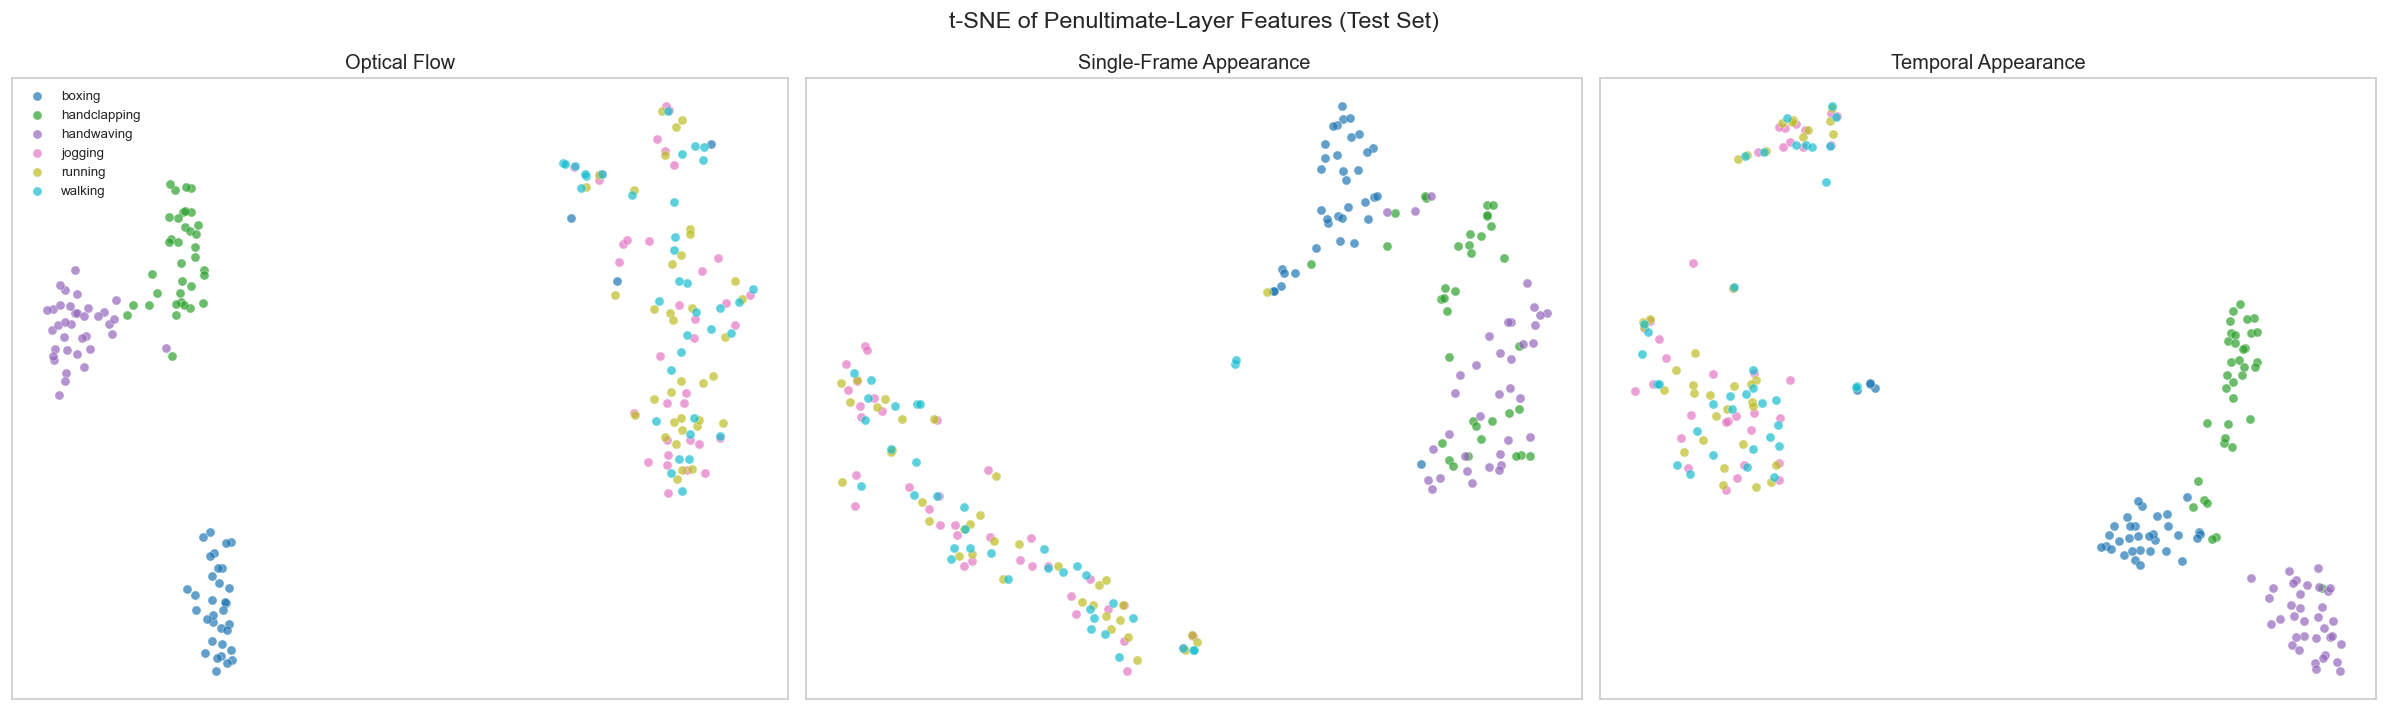

Saved outputs/tsne_features.png


In [21]:
from sklearn.manifold import TSNE


def extract_features(model, loader, device):
    """Extract avgpool features from a model for all samples in a loader."""
    model.eval()
    features_list = []
    labels_list = []
    hook_output = {}

    def hook_fn(module, input, output):
        del module, input
        hook_output["feat"] = output.flatten(1)

    handle = model.avgpool.register_forward_hook(hook_fn)
    try:
        with torch.no_grad():
            for inputs, labels in loader:
                _ = model(inputs.to(device))
                features_list.append(hook_output["feat"].cpu())
                labels_list.append(labels)
    finally:
        handle.remove()

    return torch.cat(features_list, dim=0).numpy(), torch.cat(labels_list, dim=0).numpy()


analysis_device = flow_config.device
analysis_seed = config.seed
class_names = config.class_names

print("Extracting flow features...")
flow_feats, flow_labs = extract_features(flow_best, flow_test_loader, analysis_device)
print("Extracting single-frame appearance features...")
app_single_feats, app_single_labs = extract_features(appearance_single_best, appearance_single_test_loader, analysis_device)
print("Extracting temporal appearance features...")
app_temporal_feats, app_temporal_labs = extract_features(appearance_temporal_best, appearance_temporal_test_loader, analysis_device)

flow_2d = TSNE(n_components=2, perplexity=30, random_state=analysis_seed, max_iter=1000).fit_transform(flow_feats)
app_single_2d = TSNE(n_components=2, perplexity=30, random_state=analysis_seed, max_iter=1000).fit_transform(app_single_feats)
app_temporal_2d = TSNE(n_components=2, perplexity=30, random_state=analysis_seed, max_iter=1000).fit_transform(app_temporal_feats)

colours = plt.cm.tab10(np.linspace(0, 1, len(class_names)))
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ["Optical Flow", "Single-Frame Appearance", "Temporal Appearance"]
embeddings = [flow_2d, app_single_2d, app_temporal_2d]
label_arrays = [flow_labs, app_single_labs, app_temporal_labs]

for ax, emb, labs, title in zip(axes, embeddings, label_arrays, titles):
    for idx, class_name in enumerate(class_names):
        mask = labs == idx
        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            c=[colours[idx]],
            label=class_name,
            alpha=0.7,
            s=30,
            edgecolors="w",
            linewidths=0.3,
        )
    ax.set_title(title, fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])

axes[0].legend(fontsize=8, loc="best", framealpha=0.8)
fig.suptitle("t-SNE of Penultimate-Layer Features (Test Set)", fontsize=14)
fig.tight_layout()
fig.savefig("outputs/tsne_features.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print("Saved outputs/tsne_features.png")


### 11.2 Misclassification Gallery

Flow misclassifications: 68 / 216 (31.5%)
Single-frame misclassifications: 101 / 216 (46.8%)
Temporal misclassifications: 79 / 216 (36.6%)


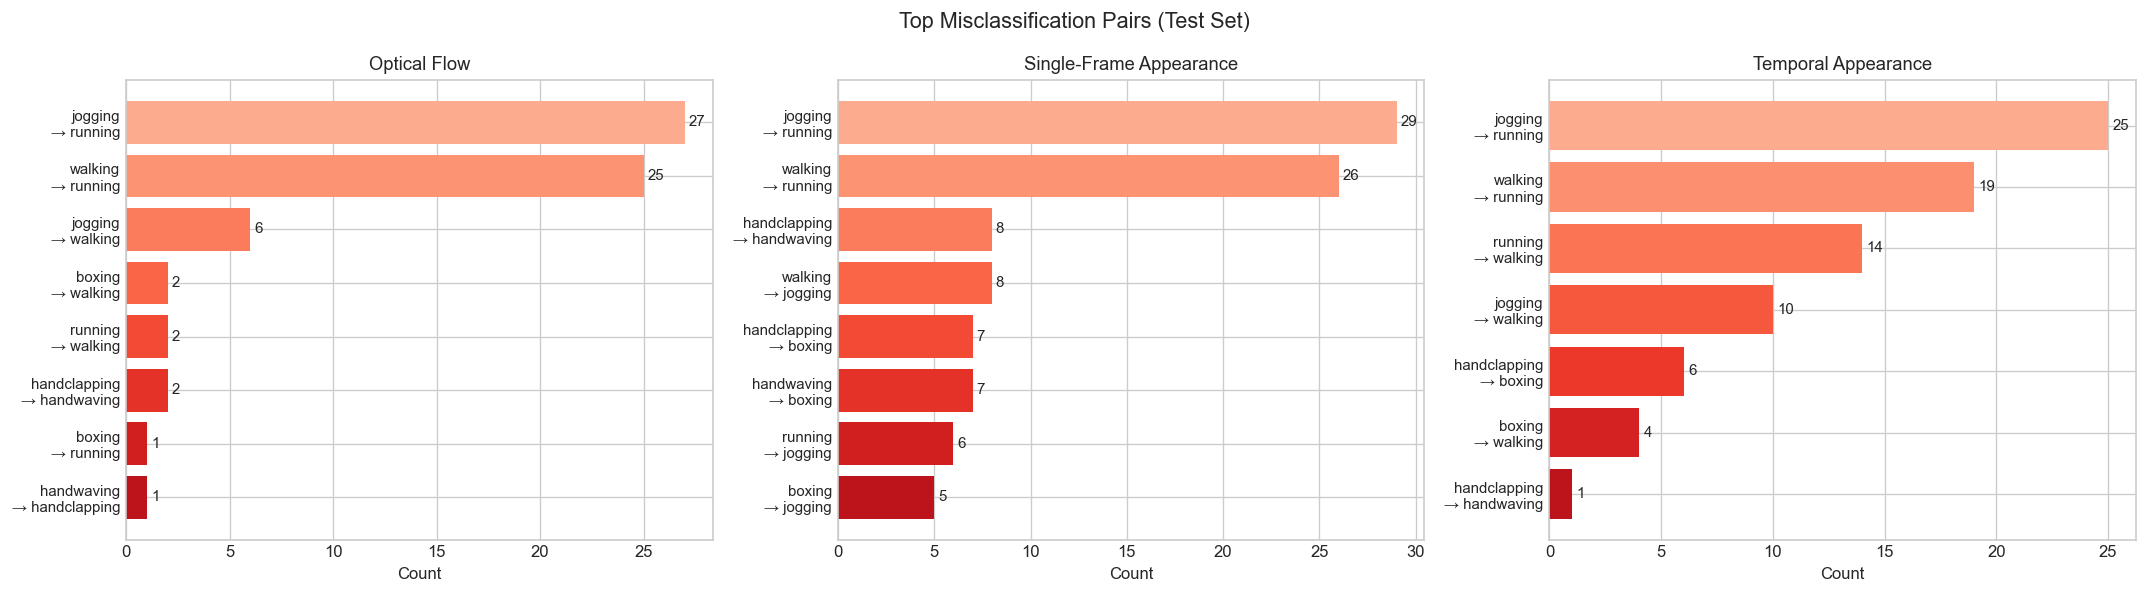

Saved outputs/misclassification_gallery.png
=== Sample Misclassified Clips (Flow) ===


,video,true_class,predicted_class
0,person18_boxing_d2_uncomp,boxing,walking
1,person22_boxing_d3_uncomp,boxing,running
2,person23_boxing_d1_uncomp,boxing,walking
3,person21_handclapping_d2_uncomp,handclapping,handwaving
4,person21_handclapping_d4_uncomp,handclapping,handwaving
5,person19_handwaving_d2_uncomp,handwaving,handclapping
6,person17_jogging_d1_uncomp,jogging,running
7,person17_jogging_d2_uncomp,jogging,running
8,person17_jogging_d3_uncomp,jogging,running
9,person17_jogging_d4_uncomp,jogging,running


=== Sample Misclassified Clips (Single-Frame) ===


,video,true_class,predicted_class
0,person22_boxing_d1_uncomp,boxing,jogging
1,person22_boxing_d2_uncomp,boxing,jogging
2,person22_boxing_d3_uncomp,boxing,jogging
3,person23_boxing_d1_uncomp,boxing,walking
4,person23_boxing_d2_uncomp,boxing,jogging
5,person23_boxing_d3_uncomp,boxing,jogging
6,person23_boxing_d4_uncomp,boxing,running
7,person17_handclapping_d1_uncomp,handclapping,handwaving
8,person18_handclapping_d1_uncomp,handclapping,handwaving
9,person18_handclapping_d2_uncomp,handclapping,handwaving


=== Sample Misclassified Clips (Temporal) ===


,video,true_class,predicted_class
0,person22_boxing_d1_uncomp,boxing,walking
1,person22_boxing_d3_uncomp,boxing,walking
2,person22_boxing_d4_uncomp,boxing,walking
3,person23_boxing_d3_uncomp,boxing,walking
4,person17_handclapping_d4_uncomp,handclapping,boxing
5,person19_handclapping_d2_uncomp,handclapping,boxing
6,person19_handclapping_d3_uncomp,handclapping,boxing
7,person21_handclapping_d1_uncomp,handclapping,boxing
8,person21_handclapping_d2_uncomp,handclapping,boxing
9,person21_handclapping_d3_uncomp,handclapping,boxing


In [22]:
def get_predictions(model, loader, device):
    """Return predicted and true labels for all samples."""
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            logits = model(inputs.to(device))
            preds.extend(logits.argmax(dim=1).cpu().tolist())
            trues.extend(labels.tolist())
    return preds, trues

# Collect predictions
flow_preds, flow_trues = get_predictions(flow_best, flow_test_loader, config.device)
app_single_preds, app_single_trues = get_predictions(appearance_single_best, appearance_single_test_loader, config.device)
app_temporal_preds, app_temporal_trues = get_predictions(appearance_temporal_best, appearance_temporal_test_loader, config.device)

# Build misclassification tables
def build_misclass_table(preds, trues, class_names, test_dirs):
    """Return a DataFrame of misclassified samples with true/predicted class and video path."""
    rows = []
    for i, (pred, true) in enumerate(zip(preds, trues)):
        if pred != true:
            video_name = Path(test_dirs[i]).name if i < len(test_dirs) else f"sample_{i}"
            rows.append({"video": video_name, "true_class": class_names[true], "predicted_class": class_names[pred]})
    return pd.DataFrame(rows)

flow_misclass = build_misclass_table(flow_preds, flow_trues, config.class_names, flow_test_dirs)
app_single_misclass = build_misclass_table(app_single_preds, app_single_trues, config.class_names, frame_test_dirs)
app_temporal_misclass = build_misclass_table(app_temporal_preds, app_temporal_trues, config.class_names, frame_test_dirs)

# Display summary
print(f"Flow misclassifications: {len(flow_misclass)} / {len(flow_trues)} ({100*len(flow_misclass)/len(flow_trues):.1f}%)")
print(f"Single-frame misclassifications: {len(app_single_misclass)} / {len(app_single_trues)} ({100*len(app_single_misclass)/len(app_single_trues):.1f}%)")
print(f"Temporal misclassifications: {len(app_temporal_misclass)} / {len(app_temporal_trues)} ({100*len(app_temporal_misclass)/len(app_temporal_trues):.1f}%)")

# Show top confusion pairs per model
def top_confusion_pairs(misclass_df, n=5):
    if misclass_df.empty:
        return pd.DataFrame(columns=["true_class", "predicted_class", "count"])
    pairs = misclass_df.groupby(["true_class", "predicted_class"]).size().reset_index(name="count")
    return pairs.sort_values("count", ascending=False).head(n).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = ["Optical Flow", "Single-Frame Appearance", "Temporal Appearance"]
misclass_dfs = [flow_misclass, app_single_misclass, app_temporal_misclass]

for ax, name, df in zip(axes, model_names, misclass_dfs):
    pairs = top_confusion_pairs(df, n=8)
    if pairs.empty:
        ax.text(0.5, 0.5, "No misclassifications", ha="center", va="center", fontsize=12)
        ax.set_title(name)
        continue
    nl = chr(10)
    pair_labels = [f"{r['true_class']}{nl}→ {r['predicted_class']}" for _, r in pairs.iterrows()]
    bars = ax.barh(range(len(pairs)), pairs["count"],
                   color=plt.cm.Reds(np.linspace(0.3, 0.8, len(pairs))))
    ax.set_yticks(range(len(pairs)))
    ax.set_yticklabels(pair_labels, fontsize=9)
    ax.set_xlabel("Count")
    ax.set_title(name, fontsize=11)
    ax.invert_yaxis()
    for bar, count in zip(bars, pairs["count"]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                str(count), va="center", fontsize=9)

fig.suptitle("Top Misclassification Pairs (Test Set)", fontsize=13)
fig.tight_layout()
fig.savefig("outputs/misclassification_gallery.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print("Saved outputs/misclassification_gallery.png")

# Show sample misclassified videos
print("=== Sample Misclassified Clips (Flow) ===")
display(flow_misclass.head(10).style.set_caption("Flow model errors"))
print("=== Sample Misclassified Clips (Single-Frame) ===")
display(app_single_misclass.head(10).style.set_caption("Single-frame model errors"))
print("=== Sample Misclassified Clips (Temporal) ===")
display(app_temporal_misclass.head(10).style.set_caption("Temporal model errors"))

### 11.3 Grad-CAM Saliency Maps

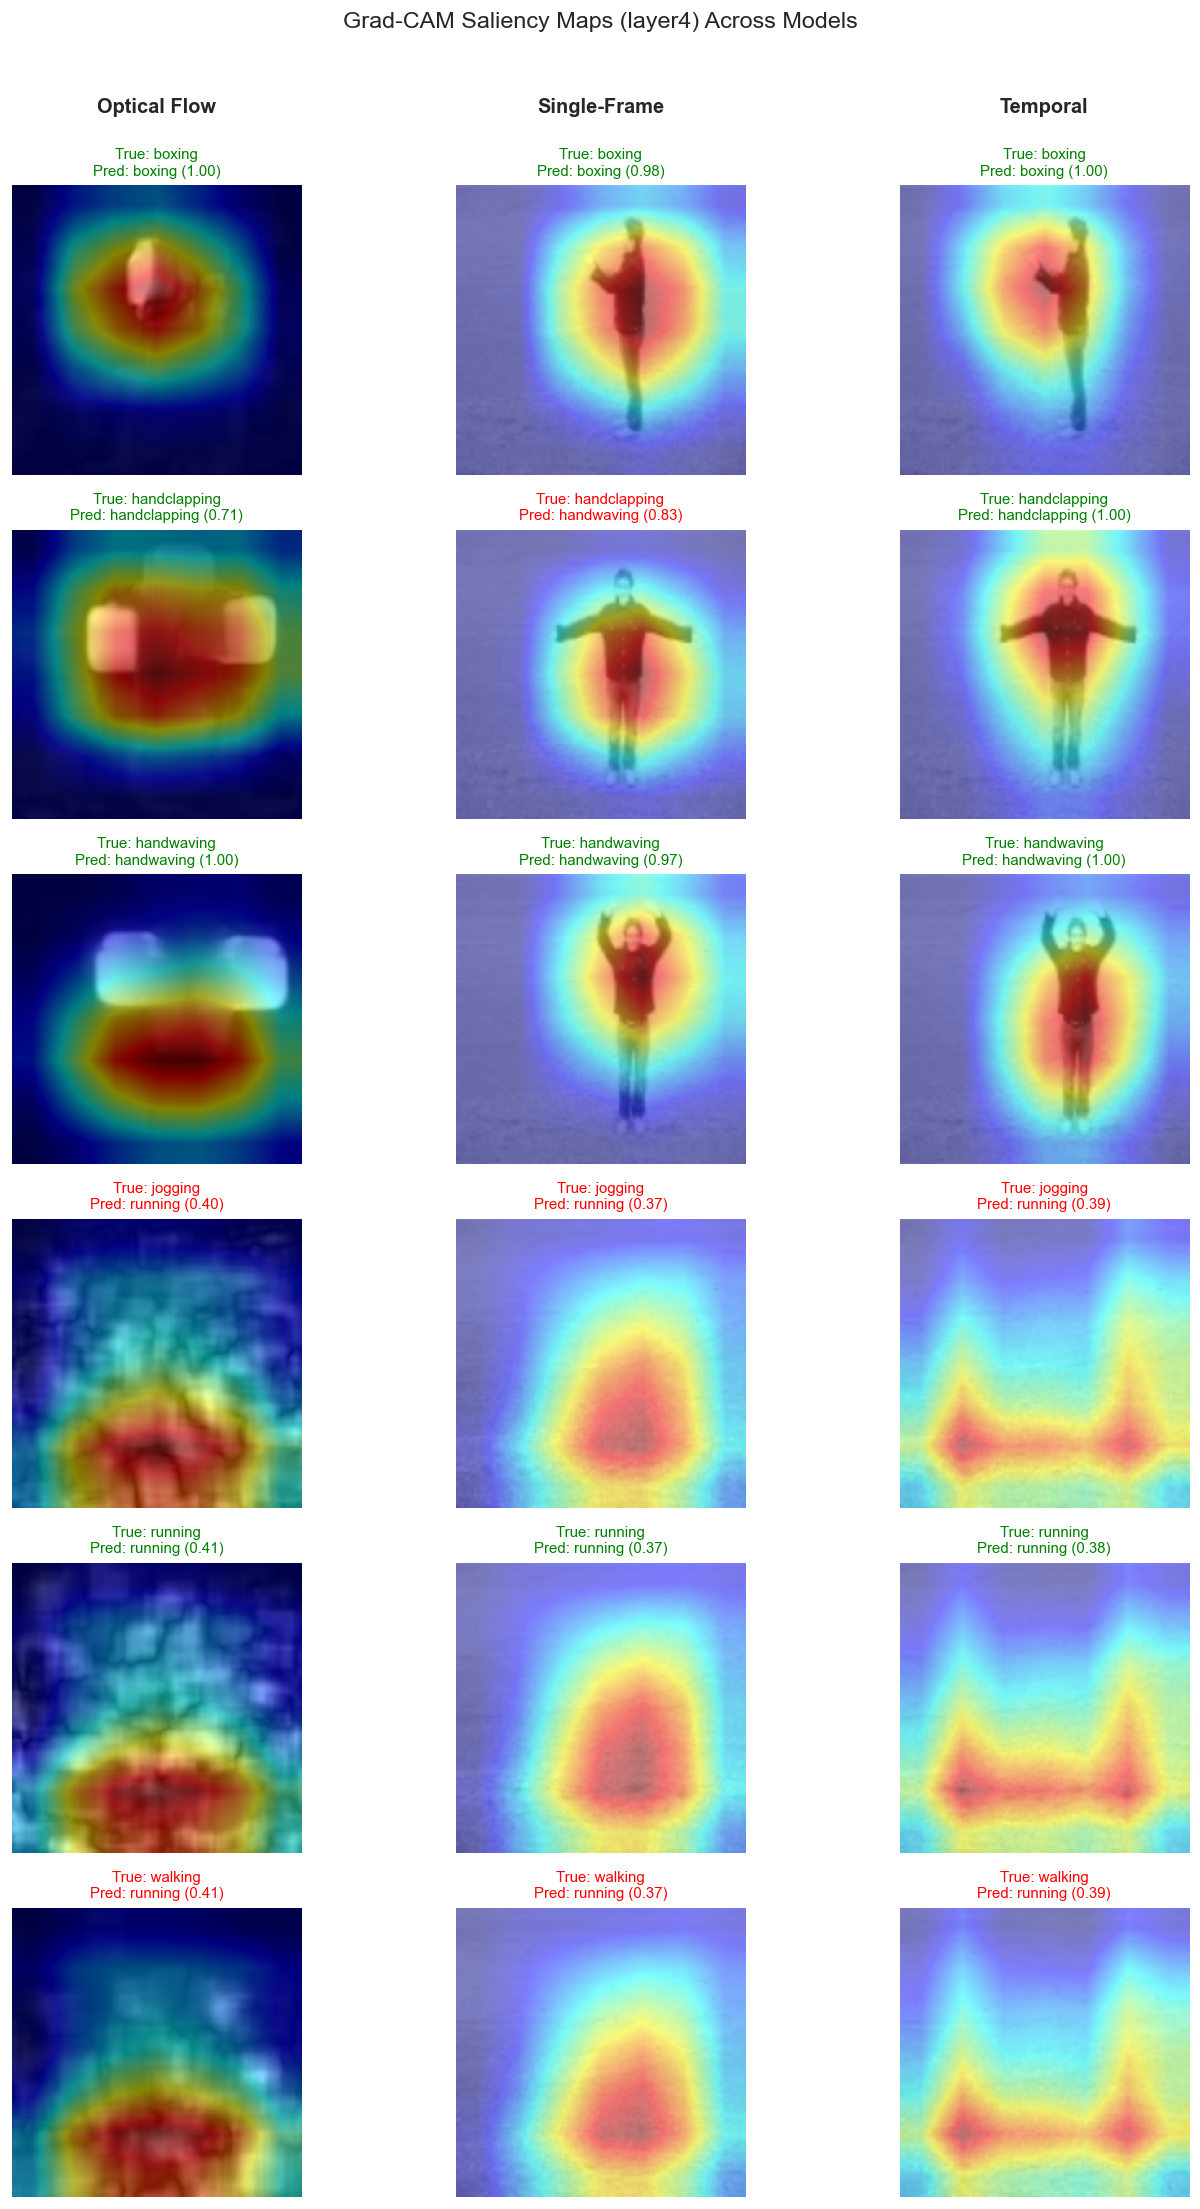

Saved outputs/gradcam_saliency.png


In [23]:
class GradCAM:
    """Minimal Grad-CAM implementation for ResNet-18 layer4."""

    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._forward_hook = target_layer.register_forward_hook(self._save_activation)
        self._backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, class_idx, output.softmax(dim=1)[0, class_idx].item()

    def remove_hooks(self):
        self._forward_hook.remove()
        self._backward_hook.remove()


def apply_gradcam_overlay(cam, height, width):
    """Resize CAM and convert to a coloured heatmap."""
    cam_resized = cv2.resize(cam, (width, height))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    return heatmap, cam_resized


# Select one test sample per class for Grad-CAM
sample_indices = {}
for idx, label in enumerate(flow_test_labels):
    if label not in sample_indices:
        sample_indices[label] = idx
    if len(sample_indices) == len(config.class_names):
        break

models_info = [
    ("Optical Flow", flow_best, flow_test_ds, flow_test_dirs),
    ("Single-Frame", appearance_single_best, appearance_single_test_ds, frame_test_dirs),
    ("Temporal", appearance_temporal_best, appearance_temporal_test_ds, frame_test_dirs),
]

n_classes = len(config.class_names)
n_models = len(models_info)
fig, axes = plt.subplots(n_classes, n_models, figsize=(4 * n_models, 3 * n_classes))

for col, (model_name, model, test_ds, test_dirs) in enumerate(models_info):
    gradcam = GradCAM(model, model.layer4)

    for row, (class_idx, sample_idx) in enumerate(sorted(sample_indices.items())):
        ax = axes[row, col]
        input_tensor, true_label = test_ds[sample_idx]
        input_tensor = input_tensor.unsqueeze(0).to(config.device)
        cam, pred_idx, confidence = gradcam.generate(input_tensor)
        heatmap, cam_resized = apply_gradcam_overlay(cam, config.resize[0], config.resize[1])

        # Create a background image for overlay
        if model_name == "Optical Flow":
            flow_data = input_tensor[0].cpu().numpy()
            mag = np.sqrt(flow_data[0]**2 + flow_data[1]**2)
            mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)
            bg = np.stack([mag, mag, mag], axis=-1)
        elif model_name == "Single-Frame":
            img = input_tensor[0].cpu()
            img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1) + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            bg = img.clamp(0, 1).permute(1, 2, 0).numpy()
        else:
            mid = input_tensor.shape[1] // 2
            gray = input_tensor[0, mid].cpu().numpy()
            gray = (gray * 0.25 + 0.5).clip(0, 1)
            bg = np.stack([gray, gray, gray], axis=-1)

        overlay = 0.5 * bg + 0.5 * heatmap
        overlay = np.clip(overlay, 0, 1)

        ax.imshow(overlay)
        pred_name = config.class_names[pred_idx]
        true_name = config.class_names[true_label]
        colour = "green" if pred_idx == true_label else "red"
        title_line1 = f"True: {true_name}"
        title_line2 = f"Pred: {pred_name} ({confidence:.2f})"
        ax.set_title(title_line1 + chr(10) + title_line2, fontsize=9, color=colour)
        ax.axis("off")

        if row == 0:
            ax.text(0.5, 1.25, model_name, transform=ax.transAxes,
                    ha="center", fontsize=12, fontweight="bold")

    gradcam.remove_hooks()

fig.suptitle("Grad-CAM Saliency Maps (layer4) Across Models", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("outputs/gradcam_saliency.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print("Saved outputs/gradcam_saliency.png")

---

## 12. Conclusion

This notebook now runs three complete experiments on the KTH Actions dataset while keeping the official person-based protocol intact:

- Persons 1-12 for training.
- Persons 13-16 for validation and checkpoint selection.
- Persons 17-25 for the final held-out test set.

The key artifacts written by the notebook are:

| Artifact | Optical Flow | Single-Frame Appearance | Temporal Appearance |
|----------|--------------|-------------------------|--------------------|
| Best checkpoint | `outputs/flow/best_flow.pt` | `outputs/appearance_single/best_appearance_single.pt` | `outputs/appearance_temporal/best_appearance_temporal.pt` |
| Training curves | `outputs/flow/training_curves_flow.png` | `outputs/appearance_single/training_curves_appearance_single.png` | `outputs/appearance_temporal/training_curves_appearance_temporal.png` |
| Confusion matrix | `outputs/flow/confusion_matrix_flow.png` | `outputs/appearance_single/confusion_matrix_appearance_single.png` | `outputs/appearance_temporal/confusion_matrix_appearance_temporal.png` |
| Metrics JSON | `outputs/flow/metrics_flow.json` | `outputs/appearance_single/metrics_appearance_single.json` | `outputs/appearance_temporal/metrics_appearance_temporal.json` |
| Comparison | `outputs/comparison.json` |  |  |

CPU runs use a smaller person-balanced train/val/test subset by default; GPU runs use the full dataset. In both cases, preprocessing stays cache-aware, so reruns skip work that has already been completed.

